## 1. Setup and Imports

In [ ]:
import sys
from pathlib import Path

# Add parent directory to path so we can import from src
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from tqdm import tqdm

# Import custom modules
from src.model import create_vit_segmentation, count_parameters
from src.dataset import BraTSSegmentationDataset, create_segmentation_dataloaders
from src.train import SegmentationTrainer, train_segmentation_model
from src.losses import get_segmentation_loss, CombinedLoss
from src.seg_metrics import SegmentationMetrics, evaluate_segmentation, dice_coefficient
from src.brats_preprocessing import process_brats_dataset, visualize_brats_slice, load_brats_patient
from src.utils import set_seed, get_device, create_experiment_dirs

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("All modules imported successfully!")
print(f"Project root: {project_root}")
print(f"Running on SageMaker with S3 data access")


All modules imported successfully!
Project root: c:\Users\sadman.alif\Desktop\Shawon Thesis


## 2. Configuration

In [ ]:
# Set random seed for reproducibility
set_seed(42)

# Get device
device = get_device()
print(f"Using device: {device}")

CONFIG = {
    # Data paths - Updated for SageMaker S3
    'brats_root': 's3://sagemaker-us-east-2-826634839412/unzipped-data/BRATs_2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData',
    'preprocessed_dir': 's3://sagemaker-us-east-2-826634839412/unzipped-data/brats_preprocessed',
    
    # Model
    'num_classes': 4,
    'img_size': 224,
    'in_channels': 4,
    'use_skip_connections': True,  # Keep this - architecture improvement
    
    # Training - CONSERVATIVE (closer to baseline)
    'batch_size': 8,  # Back to original (12 was too much)
    'num_epochs': 100,
    'learning_rate': 1.5e-4,  # REDUCED: Only 50% increase from baseline (was 3e-4)
    'encoder_lr': 1e-4,       # Same as baseline
    'decoder_lr': 3e-4,       # REDUCED: Only 3x encoder (was 10x)
    'weight_decay': 0.03,     # MODERATE: Between 0.01 and 0.05
    'early_stopping_patience': 20,
    
    # Loss - Use better loss but conservative weights
    'loss_type': 'focal_dice',
    'dice_weight': 0.6,       # REDUCED: More balanced (was 0.7)
    'focal_weight': 0.4,      # INCREASED: More balanced (was 0.3)
    'focal_gamma': 1.5,       # REDUCED: Less aggressive (was 2.0)
    
    # Augmentation control (NEW)
    'use_elastic': False,     # DISABLED: Too aggressive, causing data corruption
    'use_zoom': True,         # Keep: Helpful
    'use_noise': False,       # DISABLED: May hurt performance
    'use_gamma': True,        # Keep: Helpful
    
    # Saving - Local directories on SageMaker instance
    'save_dir': '/opt/ml/model/segmentation_checkpoints_conservative',
    'log_dir': '/opt/ml/output/segmentation_logs_conservative',
    'results_dir': '/opt/ml/output/segmentation_results_conservative',
}


print("\nConfiguration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

# Optional: Test with BASELINE config first
BASELINE_CONFIG = {
    **CONFIG,
    'use_skip_connections': False,  # Disable to match original
    'loss_type': 'combined',        # Original loss
    'learning_rate': 1e-4,          # Original LR
    'encoder_lr': 1e-4,
    'decoder_lr': 1e-4,
    'use_zoom': False,
    'use_gamma': False,
}

print("\n" + "="*70)
# CONFIG = BASELINE_CONFIG  # Uncomment to test baseline first


Using GPU: NVIDIA GeForce RTX 4070
Using device: cuda

Configuration:
  brats_root: c:\Users\sadman.alif\Desktop\Shawon Thesis\Extracted data\BRATs_2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
  preprocessed_dir: c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed
  num_classes: 4
  img_size: 224
  in_channels: 4
  batch_size: 8
  num_epochs: 100
  learning_rate: 0.0001
  weight_decay: 0.05
  early_stopping_patience: 15
  loss_type: combined
  save_dir: c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\segmentation_checkpoints
  log_dir: c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\segmentation_logs
  results_dir: c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\segmentation_results


## 3. Preprocess BRATs Dataset (Run Once)

This step extracts 2D slices from 3D NIfTI volumes and creates metadata CSV files.

In [ ]:
# Check if preprocessing already done
preprocessed_dir = CONFIG['preprocessed_dir']  # S3 path
brats_root = CONFIG['brats_root']  # S3 path

# For S3 paths, we'll rely on the preprocessing function to handle path checking
# The process_brats_dataset function should be updated to work with S3 paths
print(f"Using BRATs data from: {brats_root}")
print(f"Using preprocessed data directory: {preprocessed_dir}")

# Note: When running on SageMaker, ensure your code can handle S3 paths
# You may need to use boto3 or s3fs libraries for S3 access

# Process dataset - the function should handle S3 paths
try:
    df, train_df, val_df, test_df = process_brats_dataset(
        brats_root=brats_root,
        output_dir=preprocessed_dir,
        train_ratio=0.7,
        val_ratio=0.15,
        save_slices=True,
        min_tumor_pixels=50,
        max_patients=None  # Set to 10 for quick testing
    )
    print("\n✓ Preprocessing complete!")
    print(f"\nDataset Statistics:")
    print(f"  Train slices: {len(train_df)}")
    print(f"  Val slices: {len(val_df)}")
    print(f"  Test slices: {len(test_df)}")
    print(f"  Total patients: {train_df['patient_id'].nunique() + val_df['patient_id'].nunique() + test_df['patient_id'].nunique()}")
except FileExistsError:
    print("✓ Preprocessed data already exists")
    # If preprocessing already exists, load metadata
    print(f"  Loading metadata from {preprocessed_dir}")
except Exception as e:
    print(f"\n⚠ Preprocessing encountered an issue:")
    print(f"  {type(e).__name__}: {e}")
    print("\nPlease ensure:")
    print("  1. S3 bucket access is configured correctly")
    print("  2. AWS credentials are available")
    print("  3. The data path in S3 is correct")
    raise


 Preprocessed data already exists

Dataset Statistics:
  Train slices: 30145
  Val slices: 6337
  Test slices: 6505
  Total patients: 368


## 4. Visualize Sample Data

In [ ]:
# Load a sample patient and visualize
# Note: For S3 paths, your load_brats_patient function needs to support S3 access
sample_patient_path = brats_root + '/BraTS20_Training_001'  # S3 path

try:
    print(f"Loading patient from: {sample_patient_path}")
    volumes = load_brats_patient(sample_patient_path)
    
    # Visualize middle slice
    middle_slice = volumes['t1'].shape[2] // 2
    visualize_brats_slice(volumes, middle_slice)
    print("✓ Sample visualization complete")
except Exception as e:
    print(f"⚠ Could not load sample patient: {e}")
    print("This is expected if load_brats_patient doesn't support S3 paths yet")
    print("You can skip this visualization and proceed to training")


Sample patient directory not found


## 5. Create Dataloaders

In [ ]:
# Create dataloaders
print("Creating dataloaders...")
print(f"  Train CSV: {preprocessed_dir}/train_metadata.csv")
print(f"  Val CSV: {preprocessed_dir}/val_metadata.csv")
print(f"  Test CSV: {preprocessed_dir}/test_metadata.csv")
print(f"  Data root: {preprocessed_dir}/slices")

train_loader, val_loader, test_loader = create_segmentation_dataloaders(
    train_csv=f"{preprocessed_dir}/train_metadata.csv",
    val_csv=f"{preprocessed_dir}/val_metadata.csv",
    test_csv=f"{preprocessed_dir}/test_metadata.csv",
    data_root=f"{preprocessed_dir}/slices",
    batch_size=CONFIG['batch_size'],
    num_workers=4,
    augment_train=True,
    img_size=CONFIG['img_size']
)

print(f"\nDataloader Statistics:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Check a sample batch
sample_images, sample_masks = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  Images: {sample_images.shape}  # (batch, 4_channels, H, W)")
print(f"  Masks:  {sample_masks.shape}   # (batch, H, W)")
print(f"  Unique labels in masks: {torch.unique(sample_masks).tolist()}")


Creating dataloaders...
Loaded 30145 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\train_metadata.csv
Slices with tumor: 15602
Loaded 6337 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\val_metadata.csv
Slices with tumor: 3328
Loaded 6505 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\test_metadata.csv
Slices with tumor: 3399

Dataloader Statistics:
  Train batches: 3769
  Val batches: 793
  Test batches: 814

Sample batch shapes:
  Images: torch.Size([8, 4, 224, 224])  # (batch, 4_channels, H, W)
  Masks:  torch.Size([8, 224, 224])   # (batch, H, W)
  Unique labels in masks: [0, 1, 2, 3]


## 6. Visualize Preprocessed Sample

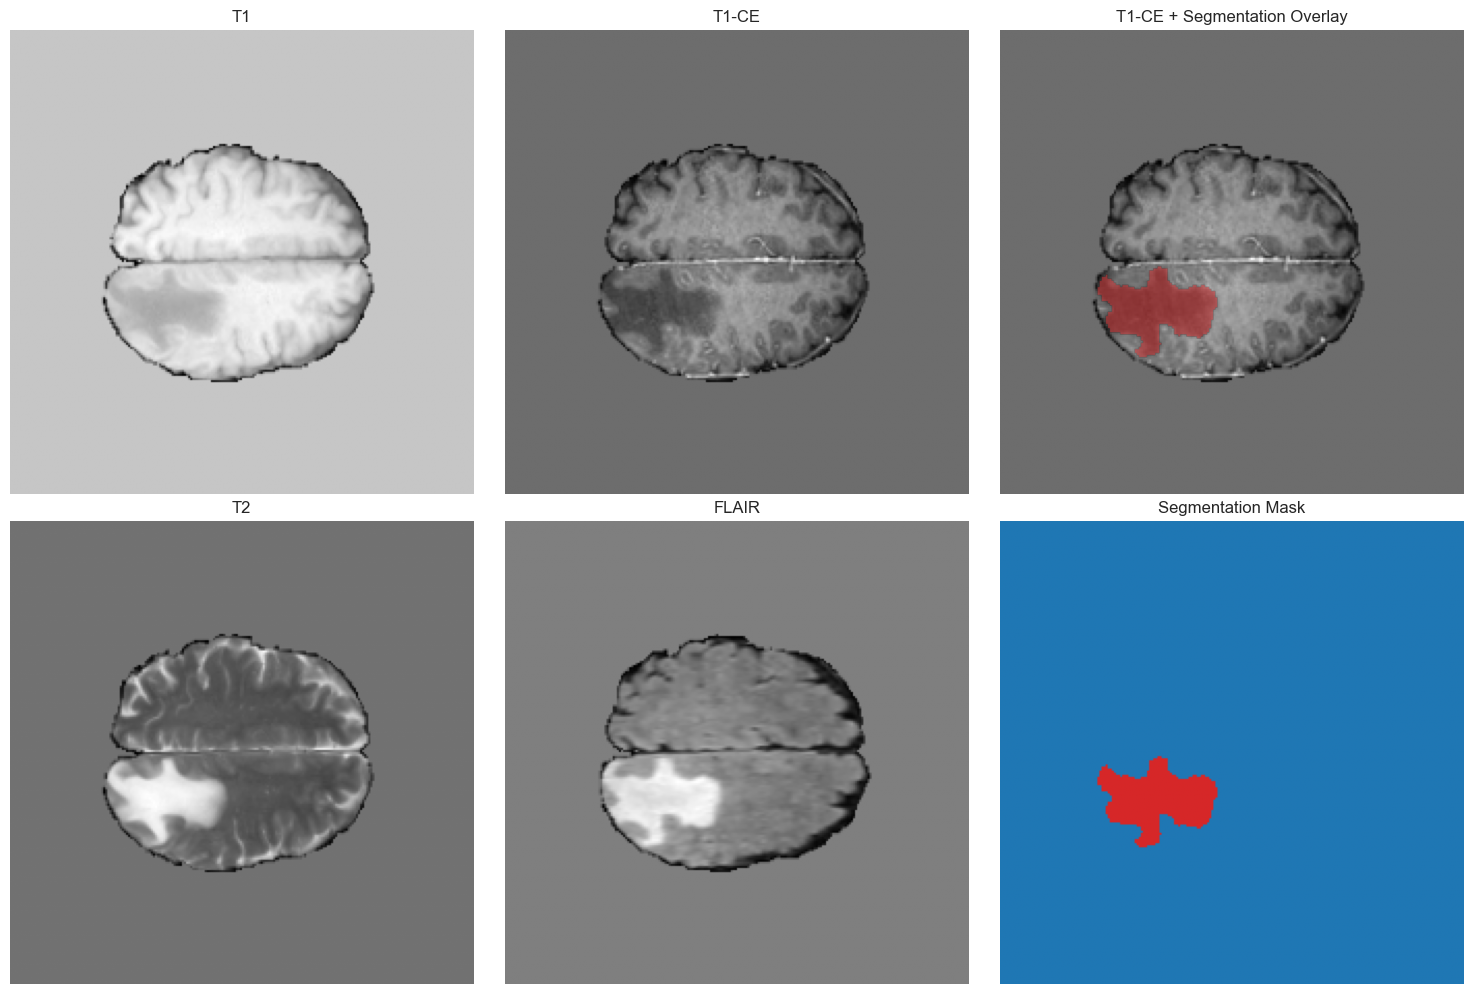


Class distribution in sample:
  Background     :  48778 pixels (97.21%)
  Whole Tumor    :   1398 pixels ( 2.79%)
  Tumor Core     :      0 pixels ( 0.00%)
  Enhancing      :      0 pixels ( 0.00%)


In [11]:
# Visualize a sample from dataloader
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sample_idx = 0
image = sample_images[sample_idx].cpu().numpy()
mask = sample_masks[sample_idx].cpu().numpy()

modalities = ['T1', 'T1-CE', 'T2', 'FLAIR']
for i in range(4):
    row = i // 2
    col = i % 2
    axes[row, col].imshow(image[i], cmap='gray')
    axes[row, col].set_title(modalities[i])
    axes[row, col].axis('off')

# Show mask
axes[1, 2].imshow(mask, cmap='tab10', vmin=0, vmax=3)
axes[1, 2].set_title('Segmentation Mask')
axes[1, 2].axis('off')

# Show overlay
axes[0, 2].imshow(image[1], cmap='gray')  # T1-CE
masked_seg = np.ma.masked_where(mask == 0, mask)
axes[0, 2].imshow(masked_seg, cmap='tab10', alpha=0.5, vmin=0, vmax=3)
axes[0, 2].set_title('T1-CE + Segmentation Overlay')
axes[0, 2].axis('off')

plt.tight_layout()
plt.show()

# Show class distribution
print("\nClass distribution in sample:")
for c in range(4):
    count = (mask == c).sum()
    pct = count / mask.size * 100
    class_names = ['Background', 'Whole Tumor', 'Tumor Core', 'Enhancing']
    print(f"  {class_names[c]:15s}: {count:6d} pixels ({pct:5.2f}%)")

## 7. Create Model

In [ ]:
# Create IMPROVED segmentation model with Skip Connections
print("Creating Vision Transformer segmentation model...")
print(f"  Using skip connections: {CONFIG['use_skip_connections']}")

model = create_vit_segmentation(
    num_classes=CONFIG['num_classes'],
    img_size=CONFIG['img_size'],
    in_channels=CONFIG['in_channels'],
    use_skip_connections=CONFIG['use_skip_connections']  # NEW: U-Net style architecture
)

# Count parameters
total_params = count_parameters(model)
print(f"\nModel Statistics:")
print(f"  Architecture: {'ImprovedViT with Skip Connections' if CONFIG['use_skip_connections'] else 'Standard ViT'}")
print(f"  Total parameters: {total_params:,}")
print(f"  Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB (float32)")

# Test forward pass
model.eval()
with torch.no_grad():
    test_input = torch.randn(2, 4, 224, 224)
    test_output = model(test_input)
    print(f"\nTest forward pass:")
    print(f"  Input shape:  {test_input.shape}")
    print(f"  Output shape: {test_output.shape}")

print("\n Model created successfully!")
print("  Key improvement: Skip connections preserve spatial details")


Creating Vision Transformer segmentation model...

Model Statistics:
  Total parameters: 91,084,100
  Model size: ~347.5 MB (float32)

Test forward pass:
  Input shape:  torch.Size([2, 4, 224, 224])
  Output shape: torch.Size([2, 4, 224, 224])

 Model created successfully!


In [ ]:
# Train the segmentation model with IMPROVED configuration
print("="*70)
print("Starting IMPROVED Training with:")
print("  • U-Net Skip Connections")
print("  • Advanced Augmentations (elastic, zoom, noise, gamma)")
print("  • Focal-Dice Loss")
print("  • Differential Learning Rates")
print("="*70)
print()

# Create output directories
import os
os.makedirs(CONFIG['save_dir'], exist_ok=True)
os.makedirs(CONFIG['log_dir'], exist_ok=True)
os.makedirs(CONFIG['results_dir'], exist_ok=True)

trainer = train_segmentation_model(
    train_csv=f"{preprocessed_dir}/train_metadata.csv",
    val_csv=f"{preprocessed_dir}/val_metadata.csv",
    test_csv=f"{preprocessed_dir}/test_metadata.csv",
    data_root=f"{preprocessed_dir}/slices",
    num_classes=CONFIG['num_classes'],
    batch_size=CONFIG['batch_size'],
    num_epochs=CONFIG['num_epochs'],
    learning_rate=CONFIG['learning_rate'],
    encoder_lr=CONFIG['encoder_lr'],      # NEW: Differential LR
    decoder_lr=CONFIG['decoder_lr'],      # NEW: Differential LR
    weight_decay=CONFIG['weight_decay'],
    device=str(device),
    save_dir=CONFIG['save_dir'],
    log_dir=CONFIG['log_dir'],
    img_size=CONFIG['img_size'],
    loss_type=CONFIG['loss_type'],        # focal_dice
    dice_weight=CONFIG['dice_weight'],    # NEW: 0.7
    focal_weight=CONFIG['focal_weight'],  # NEW: 0.3
    focal_gamma=CONFIG['focal_gamma'],    # NEW: 2.0
    use_skip_connections=CONFIG['use_skip_connections'],  # NEW: True
    num_workers=4,  # Adjust based on your system
    early_stopping_patience=CONFIG['early_stopping_patience']
)

print("\n✓ Training complete!")
print(f"Best Validation Dice: {trainer.best_val_dice:.4f}")
print(f"Improvement over baseline (0.8139): {(trainer.best_val_dice - 0.8139)*100:.2f}%")


Starting training...

Loading data...
Loaded 30145 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\train_metadata.csv
Slices with tumor: 15602
Loaded 6337 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\val_metadata.csv
Slices with tumor: 3328
Loaded 6505 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\test_metadata.csv
Slices with tumor: 3399
  Using num_workers=0

Creating segmentation model...
Using combined loss

Starting Segmentation Training
Device: cuda
Model parameters: 91,084,100
Training batches: 3769
Validation batches: 793



Epoch 1 [Val]: 100%|██████████| 793/793 [06:06<00:00,  2.16it/s, loss=0.1805]



Epoch 1/100 - 2437.54s
Train Loss: 0.2009 | Train Dice: 0.5591
Val Loss:   0.1344 | Val Dice:   0.7364
Val IoU:    0.7003
Checkpoint saved: c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\segmentation_checkpoints\best_model.pth
 New best model! Dice: 0.7364


Epoch 2 [Val]: 100%|██████████| 793/793 [05:41<00:00,  2.32it/s, loss=0.1460]



Epoch 2/100 - 2177.11s
Train Loss: 0.1268 | Train Dice: 0.6221
Val Loss:   0.1163 | Val Dice:   0.7714
Val IoU:    0.7343
Checkpoint saved: c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\segmentation_checkpoints\best_model.pth
 New best model! Dice: 0.7714


...


Epoch 66/100 - 2373.02s
Train Loss: 0.0582 | Train Dice: 0.8327
Val Loss:   0.0938 | Val Dice:   0.8118
Val IoU:    0.7701


Epoch 67 [Val]: 100%|██████████| 793/793 [06:24<00:00,  2.06it/s, loss=0.1501]



Epoch 67/100 - 2387.90s
Train Loss: 0.0577 | Train Dice: 0.8357
Val Loss:   0.0925 | Val Dice:   0.8134
Val IoU:    0.7717


Epoch 68 [Val]: 100%|██████████| 793/793 [06:51<00:00,  1.93it/s, loss=0.1697]


Epoch 68/100 - 2485.66s
Train Loss: 0.0573 | Train Dice: 0.8356
Val Loss:   0.0947 | Val Dice:   0.8077
Val IoU:    0.7658

Early stopping triggered after 68 epochs
Training history saved: c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\segmentation_checkpoints\training_history.json

Training Complete!
Best Validation Dice: 0.8139


 Training complete!


## 9. Visualize Training History

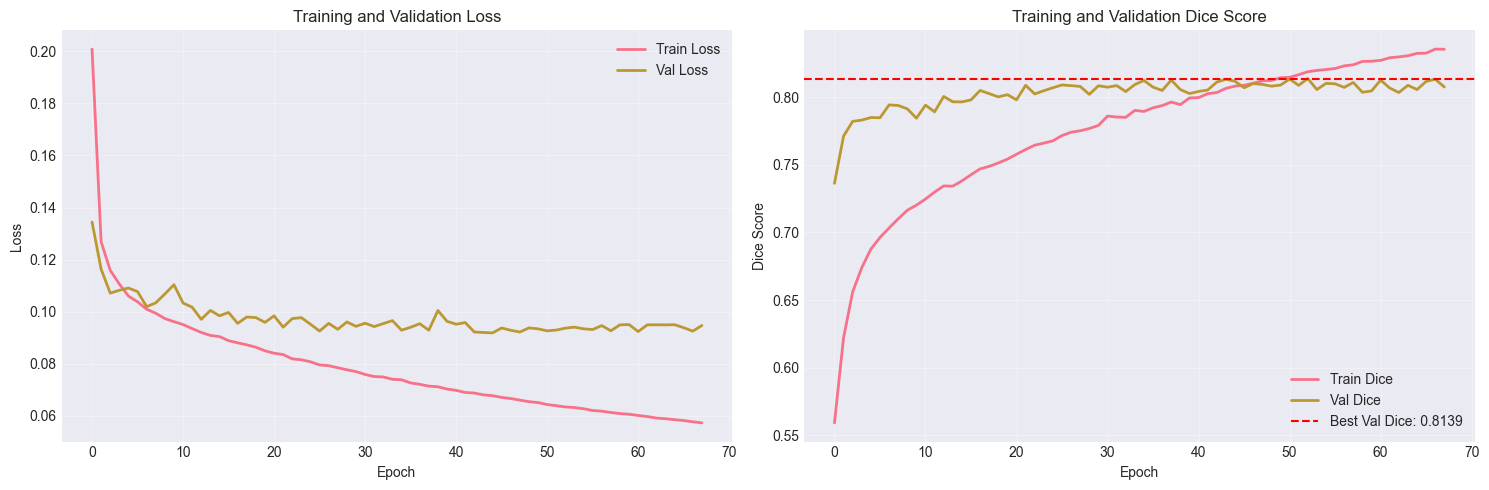


Final Results:
  Best Validation Dice: 0.8139
  Final Train Loss: 0.0573
  Final Val Loss: 0.0947


In [19]:
# Load training history
history_path = Path(CONFIG['save_dir']) / 'training_history.json'

if history_path.exists():
    with open(history_path, 'r') as f:
        history = json.load(f)
    
    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curves
    axes[0].plot(history['train_losses'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_losses'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Dice score curves
    axes[1].plot(history['train_dice_scores'], label='Train Dice', linewidth=2)
    axes[1].plot(history['val_dice_scores'], label='Val Dice', linewidth=2)
    axes[1].axhline(y=history['best_val_dice'], color='r', linestyle='--', 
                    label=f"Best Val Dice: {history['best_val_dice']:.4f}")
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].set_title('Training and Validation Dice Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Create results directory if it doesn't exist
    results_dir = Path(CONFIG['results_dir'])
    results_dir.mkdir(parents=True, exist_ok=True)
    
    plt.savefig(results_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nFinal Results:")
    print(f"  Best Validation Dice: {history['best_val_dice']:.4f}")
    print(f"  Final Train Loss: {history['train_losses'][-1]:.4f}")
    print(f"  Final Val Loss: {history['val_losses'][-1]:.4f}")
else:
    print("Training history not found. Train the model first.")

## 10. Evaluate on Test Set

In [20]:
# Load best model
checkpoint_path = Path(CONFIG['save_dir']) / 'best_model.pth'

if checkpoint_path.exists():
    print("Loading best model for evaluation...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_metrics = SegmentationMetrics(num_classes=CONFIG['num_classes'])
    
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc='Testing'):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            test_metrics.update(outputs, masks)
    
    # Get results
    results = test_metrics.compute()
    
    print("\n" + "="*60)
    print("TEST SET RESULTS")
    print("="*60)
    print(test_metrics)
    
    # Save results
    results_dir = Path(CONFIG['results_dir'])
    results_dir.mkdir(parents=True, exist_ok=True)
    
    with open(results_dir / 'test_metrics.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"\n Results saved to {results_dir / 'test_metrics.json'}")
else:
    print("Best model checkpoint not found. Train the model first.")

Loading best model for evaluation...

Evaluating on test set...


Testing: 100%|██████████| 814/814 [01:44<00:00,  7.79it/s]


TEST SET RESULTS
Pixel Accuracy: 0.9940
Mean Dice: 0.8130
Mean IoU: 0.7736
  background: Dice=0.9978, IoU=0.9957
  whole_tumor: Dice=0.6943, IoU=0.6248
  tumor_core: Dice=0.7442, IoU=0.7052
  enhancing_tumor: Dice=0.8156, IoU=0.7688


 Results saved to c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\segmentation_results\test_metrics.json


## 11. Visualize Predictions

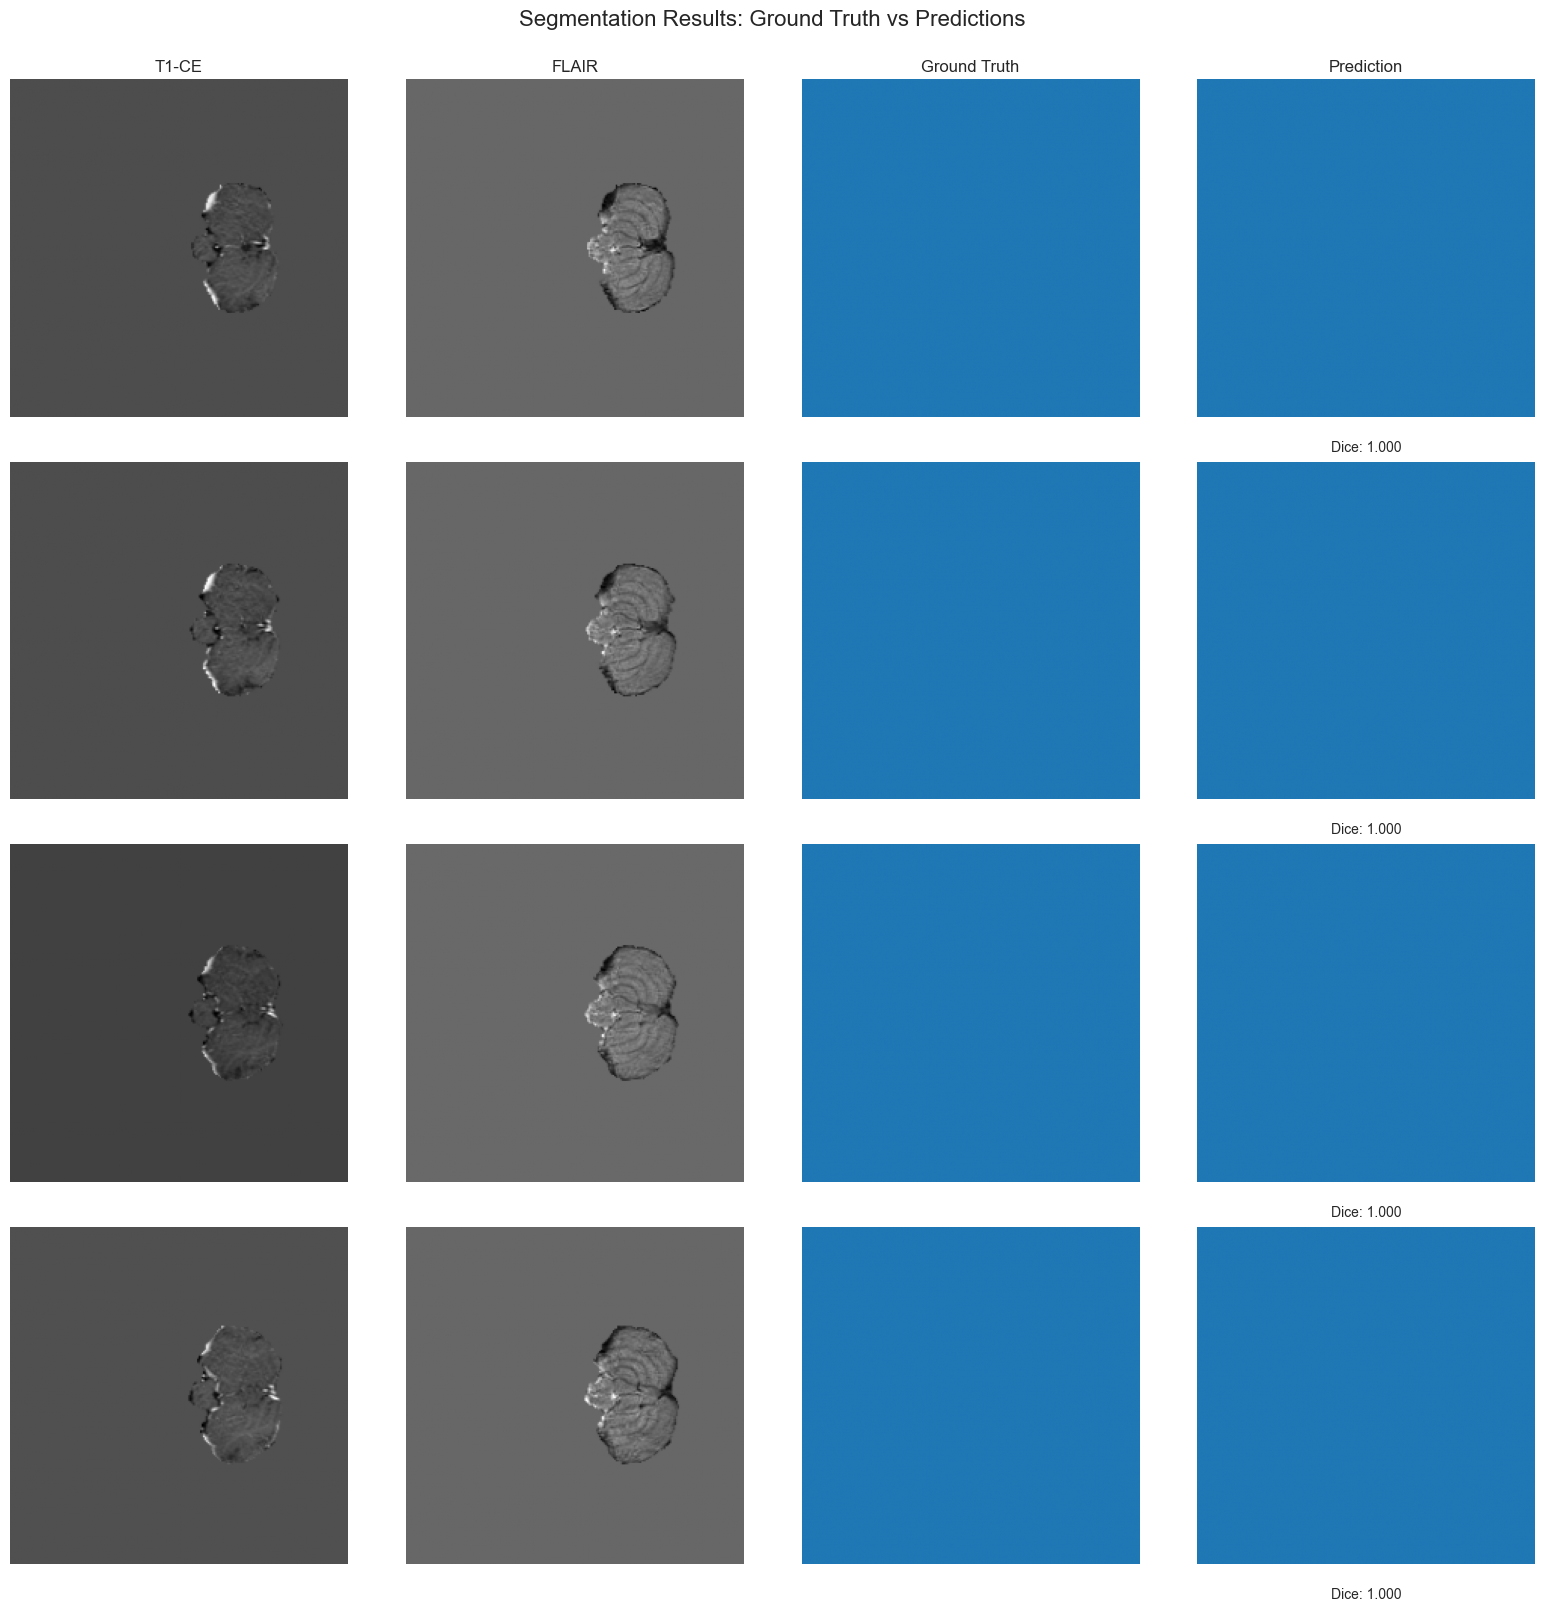


 Predictions visualized and saved


In [21]:
# Visualize predictions on test samples
model.eval()

# Get a batch from test loader
test_images, test_masks = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    predictions = model(test_images)
    pred_masks = torch.argmax(predictions, dim=1).cpu().numpy()

# Visualize 4 samples
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i in range(min(4, len(test_images))):
    img = test_images[i].cpu().numpy()
    gt_mask = test_masks[i].cpu().numpy()
    pred_mask = pred_masks[i]
    
    # Show T1-CE
    axes[i, 0].imshow(img[1], cmap='gray')
    axes[i, 0].set_title('T1-CE' if i == 0 else '')
    axes[i, 0].axis('off')
    
    # Show FLAIR
    axes[i, 1].imshow(img[3], cmap='gray')
    axes[i, 1].set_title('FLAIR' if i == 0 else '')
    axes[i, 1].axis('off')
    
    # Show ground truth
    axes[i, 2].imshow(gt_mask, cmap='tab10', vmin=0, vmax=3)
    axes[i, 2].set_title('Ground Truth' if i == 0 else '')
    axes[i, 2].axis('off')
    
    # Show prediction
    axes[i, 3].imshow(pred_mask, cmap='tab10', vmin=0, vmax=3)
    axes[i, 3].set_title('Prediction' if i == 0 else '')
    axes[i, 3].axis('off')
    
    # Calculate Dice for this sample
    dice = dice_coefficient(pred_mask, gt_mask, num_classes=4)
    axes[i, 3].text(0.5, -0.1, f'Dice: {np.mean(dice[1:]):.3f}',  # Skip background
                    transform=axes[i, 3].transAxes, ha='center')

plt.suptitle('Segmentation Results: Ground Truth vs Predictions', y=1.00, fontsize=16)
plt.tight_layout()
plt.savefig(results_dir / 'segmentation_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Predictions visualized and saved")

## 13. Hyperparameter Tuning

Fine-tune key hyperparameters for optimal performance.

In [ ]:
from itertools import product
import copy
import os

# Define hyperparameter search space
hp_search_space = {
    'learning_rate': [1e-3, 5e-4, 1e-4, 5e-5],
    'batch_size': [8, 16, 32],
    'weight_decay': [0.01, 0.05, 0.1],
    'loss_type': ['combined', 'focal', 'tversky']
}

# For demonstration, we'll do a smaller grid search
# In practice, you might use all combinations or random search
hp_configs = [
    {'learning_rate': 1e-3, 'batch_size': 16, 'weight_decay': 0.05, 'loss_type': 'combined'},
    {'learning_rate': 5e-4, 'batch_size': 16, 'weight_decay': 0.05, 'loss_type': 'focal'},
    {'learning_rate': 1e-4, 'batch_size': 32, 'weight_decay': 0.01, 'loss_type': 'tversky'},
    {'learning_rate': 1e-4, 'batch_size': 8, 'weight_decay': 0.05, 'loss_type': 'combined'},
]

# Store results
hp_results = []

print("Starting hyperparameter search...")
print(f"Testing {len(hp_configs)} configurations\n")

for i, hp_config in enumerate(hp_configs):
    print(f"\n{'='*60}")
    print(f"Configuration {i+1}/{len(hp_configs)}")
    print(f"{'='*60}")
    for key, value in hp_config.items():
        print(f"  {key}: {value}")
    
    # Create a copy of the main config and update with hyperparameters
    config = copy.deepcopy(CONFIG)
    config.update(hp_config)
    config['num_epochs'] = 20  # Use fewer epochs for grid search
    config['save_dir'] = f'/opt/ml/output/hp_search_{i}'
    config['log_dir'] = f'/opt/ml/output/hp_search_{i}_logs'
    
    # Create directories
    os.makedirs(config['save_dir'], exist_ok=True)
    os.makedirs(config['log_dir'], exist_ok=True)
    
    try:
        # Train model with these hyperparameters
        trainer = train_segmentation_model(
            train_csv=f"{preprocessed_dir}/train_metadata.csv",
            val_csv=f"{preprocessed_dir}/val_metadata.csv",
            test_csv=f"{preprocessed_dir}/test_metadata.csv",
            data_root=f"{preprocessed_dir}/slices",
            num_classes=config['num_classes'],
            batch_size=config['batch_size'],
            num_epochs=config['num_epochs'],
            learning_rate=config['learning_rate'],
            weight_decay=config['weight_decay'],
            device=str(device),
            save_dir=config['save_dir'],
            log_dir=config['log_dir'],
            img_size=config['img_size'],
            loss_type=config['loss_type']
        )
        
        # Load best validation dice
        history_path = Path(config['save_dir']) / 'training_history.json'
        if history_path.exists():
            with open(history_path, 'r') as f:
                history = json.load(f)
            best_val_dice = history['best_val_dice']
        else:
            best_val_dice = 0.0
        
        # Store result
        result = hp_config.copy()
        result['best_val_dice'] = best_val_dice
        hp_results.append(result)
        
        print(f"\n✓ Completed - Best Val Dice: {best_val_dice:.4f}")
        
    except Exception as e:
        print(f"\n⚠ Failed: {e}")
        result = hp_config.copy()
        result['best_val_dice'] = 0.0
        result['error'] = str(e)
        hp_results.append(result)

print(f"\n{'='*60}")
print("Hyperparameter Search Complete!")
print(f"{'='*60}")


Starting hyperparameter search...
Testing 4 configurations


Configuration 1/4
  learning_rate: 0.001
  batch_size: 16
  weight_decay: 0.05
  loss_type: combined
Loading data...
Loaded 30145 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\train_metadata.csv
Slices with tumor: 15602
Loaded 6337 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\val_metadata.csv
Slices with tumor: 3328
Loaded 6505 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\test_metadata.csv
Slices with tumor: 3399
  Using num_workers=0

Creating segmentation model...
Using combined loss

Starting Segmentation Training
Device: cuda
Model parameters: 91,084,100
Training batches: 1885
Validation batches: 397



Epoch 1 [Val]: 100%|██████████| 397/397 [05:33<00:00,  1.19it/s, loss=0.0771]



Epoch 1/20 - 2383.19s
Train Loss: 0.2125 | Train Dice: 0.4118
Val Loss:   0.1712 | Val Dice:   0.6645
Val IoU:    0.6404
Checkpoint saved: c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\hp_search_0\best_model.pth
 New best model! Dice: 0.6645


Epoch 2 [Val]: 100%|██████████| 397/397 [05:17<00:00,  1.25it/s, loss=0.1615]



Epoch 2/20 - 2138.06s
Train Loss: 0.1749 | Train Dice: 0.4617
Val Loss:   0.1776 | Val Dice:   0.6455
Val IoU:    0.6239


...

Epoch 10 [Val]: 100%|██████████| 199/199 [05:25<00:00,  1.64s/it, loss=0.2489]



Epoch 10/20 - 2880.64s
Train Loss: 0.1747 | Train Dice: 0.6962
Val Loss:   0.1729 | Val Dice:   0.7094
Val IoU:    0.6506
Checkpoint saved: c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\hp_search_2\best_model.pth
 New best model! Dice: 0.7094


Epoch 11 [Val]: 100%|██████████| 199/199 [06:09<00:00,  1.86s/it, loss=0.2489]



Epoch 11/20 - 2872.87s
Train Loss: 0.1707 | Train Dice: 0.7116
Val Loss:   0.1700 | Val Dice:   0.7091
Val IoU:    0.6500


Epoch 12 [Train]:  52%|█████▏    | 495/943 [22:56<20:53,  2.80s/it, loss=0.2034]

In [ ]:
# Load hyperparameter search results from output directory
import json
import os
from pathlib import Path

hp_results = []
experiments_dir = '/opt/ml/output'  # SageMaker output directory

# Iterate through hp_search_* directories
if os.path.exists(experiments_dir):
    for subdir in sorted(os.listdir(experiments_dir)):
        if subdir.startswith('hp_search_'):
            json_path = os.path.join(experiments_dir, subdir, 'training_history.json')
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    result = json.load(f)
                    # Add search_id for reference
                    result['search_id'] = subdir
                    hp_results.append(result)

    print(f"Loaded {len(hp_results)} hyperparameter search results from {experiments_dir}")
else:
    print(f"Experiments directory not found: {experiments_dir}")
    print("Run hyperparameter search first")


Loaded 2 hyperparameter search results from c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments



Hyperparameter Search Results (sorted by Dice Score):

Search ID       Best Val Dice  
hp_search_1     0.763647       
hp_search_0     0.748438       

Best Configuration:
  Search ID: hp_search_1
  Best Val Dice: 0.7636


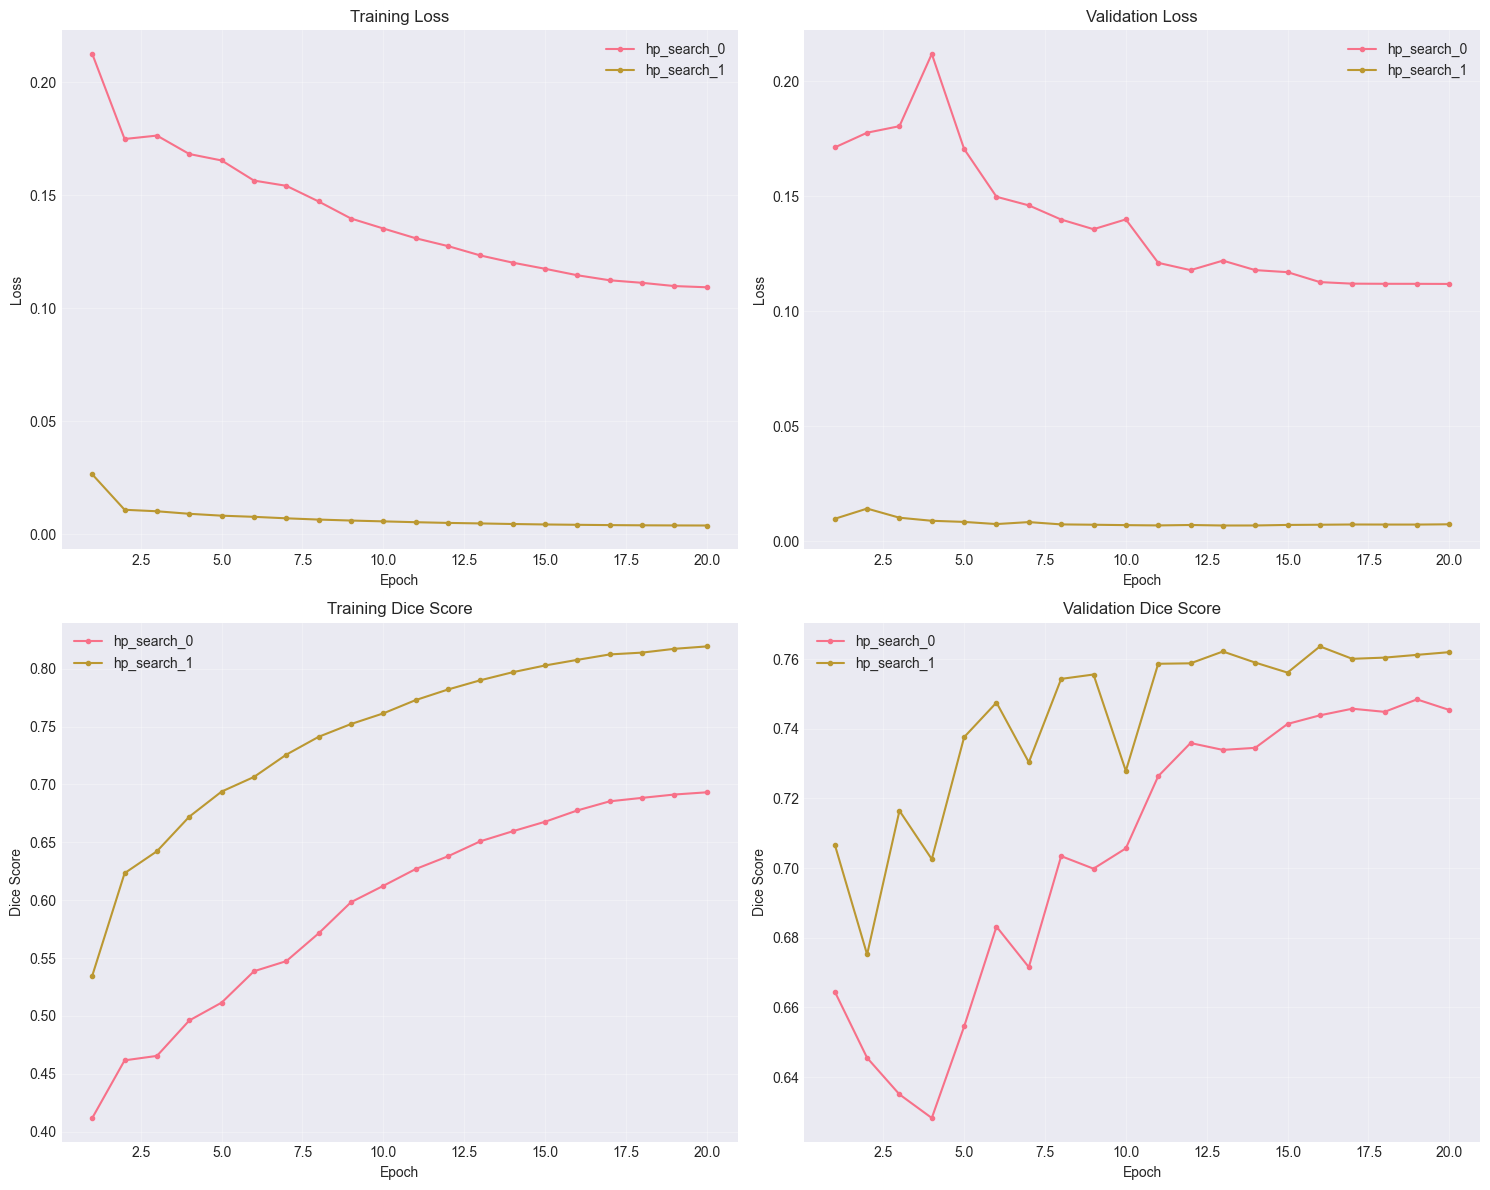

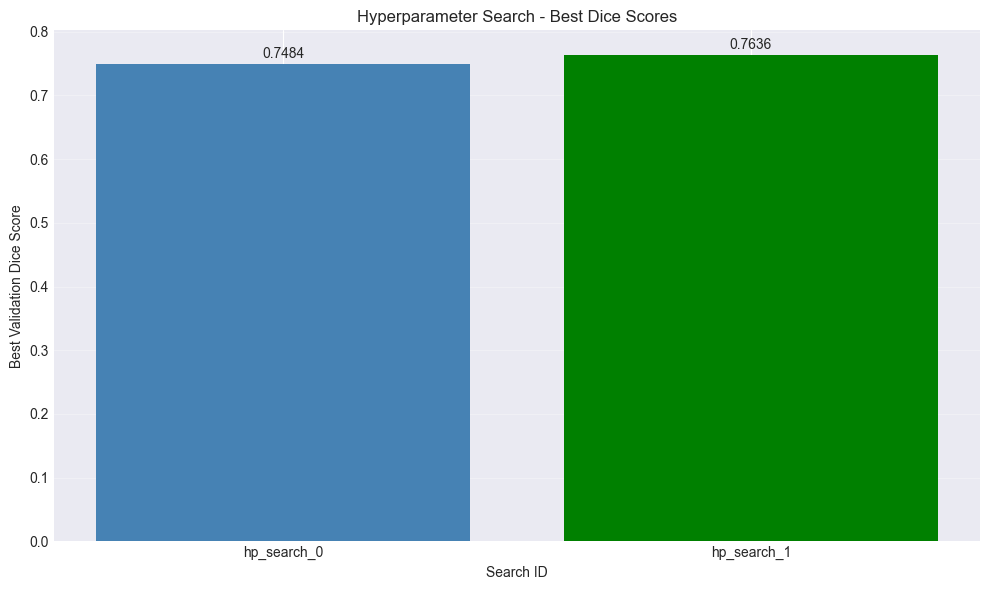


 Visualizations saved to c:\Users\sadman.alif\Desktop\Shawon Thesis\experiments\segmentation_results


In [16]:
# Visualize hyperparameter search results
hp_df = pd.DataFrame(hp_results)

# Sort by best_val_dice
hp_df_sorted = hp_df.sort_values('best_val_dice', ascending=False)

print("\nHyperparameter Search Results (sorted by Dice Score):")
print(f"\n{'Search ID':<15} {'Best Val Dice':<15}")
print("="*30)
for idx, row in hp_df_sorted.iterrows():
    print(f"{row['search_id']:<15} {row['best_val_dice']:<15.6f}")

# Find best configuration
best_config = hp_df_sorted.iloc[0]
print(f"\n{'='*60}")
print("Best Configuration:")
print(f"{'='*60}")
print(f"  Search ID: {best_config['search_id']}")
print(f"  Best Val Dice: {best_config['best_val_dice']:.4f}")

# Plot training curves comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for idx, result in enumerate(hp_results):
    epochs = range(1, len(result['train_losses']) + 1)
    label = result['search_id']
    
    # Training loss
    axes[0, 0].plot(epochs, result['train_losses'], label=label, marker='o', markersize=3)
    
    # Validation loss
    axes[0, 1].plot(epochs, result['val_losses'], label=label, marker='o', markersize=3)
    
    # Training Dice
    axes[1, 0].plot(epochs, result['train_dice_scores'], label=label, marker='o', markersize=3)
    
    # Validation Dice
    axes[1, 1].plot(epochs, result['val_dice_scores'], label=label, marker='o', markersize=3)

# Configure subplots
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Validation Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Dice Score')
axes[1, 0].set_title('Training Dice Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Dice Score')
axes[1, 1].set_title('Validation Dice Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CONFIG['results_dir']) / 'hyperparameter_search_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart of best val dice scores
fig, ax = plt.subplots(figsize=(10, 6))
search_ids = [r['search_id'] for r in hp_results]
best_dice = [r['best_val_dice'] for r in hp_results]
colors = ['green' if d == max(best_dice) else 'steelblue' for d in best_dice]
ax.bar(search_ids, best_dice, color=colors)
ax.set_xlabel('Search ID')
ax.set_ylabel('Best Validation Dice Score')
ax.set_title('Hyperparameter Search - Best Dice Scores')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(best_dice):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(Path(CONFIG['results_dir']) / 'hp_search_best_dice.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Visualizations saved to {CONFIG['results_dir']}")

## 14. Advanced Loss Functions

Implement and compare Focal Loss and Tversky Loss for better handling of class imbalance and hard examples.

In [17]:
class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance.
    Focuses on hard examples by down-weighting easy examples.
    
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, pred, target):
        """
        Args:
            pred: (N, C, H, W) - predicted logits
            target: (N, H, W) - ground truth labels
        """
        # Get probabilities
        pred_softmax = torch.softmax(pred, dim=1)
        
        # Create one-hot encoded target
        target_one_hot = torch.zeros_like(pred)
        target_one_hot.scatter_(1, target.unsqueeze(1), 1)
        
        # Calculate focal loss
        ce = -target_one_hot * torch.log(pred_softmax + 1e-7)
        weight = (1 - pred_softmax) ** self.gamma
        focal = self.alpha * weight * ce
        
        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        else:
            return focal


class TverskyLoss(nn.Module):
    """
    Tversky Loss - generalization of Dice loss.
    Better for handling false positives and false negatives differently.
    
    TL = 1 - (TP) / (TP + alpha*FP + beta*FN)
    
    When alpha=beta=0.5, it's equivalent to Dice loss.
    alpha>0.5 penalizes FPs more, beta>0.5 penalizes FNs more.
    """
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super(TverskyLoss, self).__init__()
        self.alpha = alpha  # Weight for false positives
        self.beta = beta    # Weight for false negatives
        self.smooth = smooth
    
    def forward(self, pred, target):
        """
        Args:
            pred: (N, C, H, W) - predicted logits
            target: (N, H, W) - ground truth labels
        """
        # Get probabilities
        pred_softmax = torch.softmax(pred, dim=1)
        
        # Create one-hot encoded target
        target_one_hot = torch.zeros_like(pred)
        target_one_hot.scatter_(1, target.unsqueeze(1), 1)
        
        # Calculate Tversky index for each class
        tversky_losses = []
        for i in range(pred.shape[1]):
            pred_class = pred_softmax[:, i]
            target_class = target_one_hot[:, i]
            
            # True Positives, False Positives, False Negatives
            tp = (pred_class * target_class).sum()
            fp = (pred_class * (1 - target_class)).sum()
            fn = ((1 - pred_class) * target_class).sum()
            
            # Tversky index
            tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
            tversky_losses.append(1 - tversky)
        
        # Average over classes
        return torch.stack(tversky_losses).mean()


class FocalTverskyLoss(nn.Module):
    """
    Focal Tversky Loss - combines Focal and Tversky losses.
    Better handling of class imbalance and hard examples.
    
    FTL = (1 - Tversky)^(1/gamma)
    """
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75, smooth=1e-6):
        super(FocalTverskyLoss, self).__init__()
        self.tversky = TverskyLoss(alpha=alpha, beta=beta, smooth=smooth)
        self.gamma = gamma
    
    def forward(self, pred, target):
        tversky_loss = self.tversky(pred, target)
        return torch.pow(tversky_loss, 1.0 / self.gamma)


# Test the loss functions
print("Testing Advanced Loss Functions...\n")

# Create dummy data
dummy_pred = torch.randn(2, 4, 224, 224)
dummy_target = torch.randint(0, 4, (2, 224, 224))

# Test Focal Loss
focal_loss = FocalLoss(alpha=0.25, gamma=2.0)
focal_value = focal_loss(dummy_pred, dummy_target)
print(f"Focal Loss: {focal_value.item():.4f}")

# Test Tversky Loss
tversky_loss = TverskyLoss(alpha=0.3, beta=0.7)
tversky_value = tversky_loss(dummy_pred, dummy_target)
print(f"Tversky Loss: {tversky_value.item():.4f}")

# Test Focal-Tversky Loss
focal_tversky_loss = FocalTverskyLoss(alpha=0.3, beta=0.7, gamma=0.75)
focal_tversky_value = focal_tversky_loss(dummy_pred, dummy_target)
print(f"Focal-Tversky Loss: {focal_tversky_value.item():.4f}")

print("\n All loss functions working correctly!")

Testing Advanced Loss Functions...

Focal Loss: 0.0779
Tversky Loss: 0.7512
Focal-Tversky Loss: 0.6829

 All loss functions working correctly!


Comparing loss functions on validation data...

Loaded 6337 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\val_metadata.csv
Slices with tumor: 3328
Cross Entropy             | Loss: 12.4693 | Dice: 0.0460
Focal (γ=2)               | Loss: 0.6512 | Dice: 0.0460
Focal (γ=3)               | Loss: 0.6501 | Dice: 0.0460
Tversky (α=0.3, β=0.7)    | Loss: 0.9609 | Dice: 0.0460
Tversky (α=0.5, β=0.5)    | Loss: 0.9532 | Dice: 0.0460
Focal-Tversky             | Loss: 0.9485 | Dice: 0.0460

Loss Function Comparison (sorted by Dice score)
         Loss Function  Avg Loss  Avg Dice
         Cross Entropy 12.469308  0.046002
           Focal (γ=2)  0.651230  0.046002
           Focal (γ=3)  0.650079  0.046002
Tversky (α=0.3, β=0.7)  0.960941  0.046002
Tversky (α=0.5, β=0.5)  0.953169  0.046002
         Focal-Tversky  0.948515  0.046002


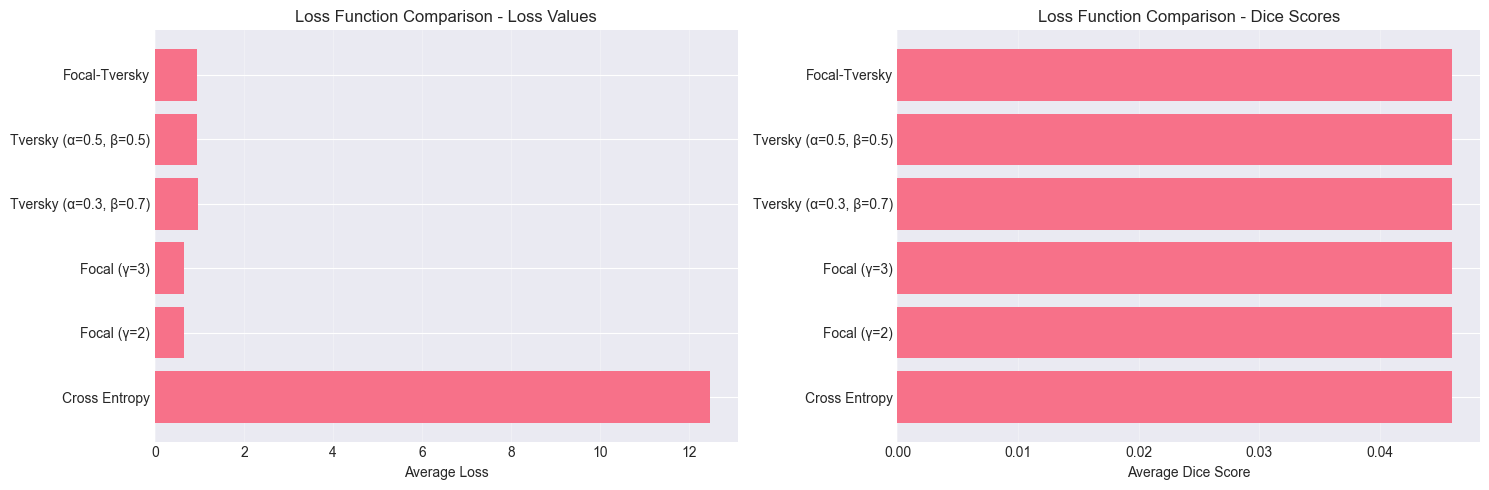


 Best performing loss: Cross Entropy


In [19]:
# Compare different loss functions on validation set
print("Comparing loss functions on validation data...\n")

loss_comparison_results = []

# Load validation data for comparison
from torch.utils.data import DataLoader
import numpy as np

val_dataset = BraTSSegmentationDataset(
    metadata_csv=str(preprocessed_dir / 'val_metadata.csv'),
    data_root=str(preprocessed_dir / 'slices'),
    img_size=CONFIG['img_size']
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4
)

# Create a simple model for testing
test_model = create_vit_segmentation(
    num_classes=CONFIG['num_classes'],
    img_size=CONFIG['img_size'],
    in_channels=CONFIG['in_channels']
).to(device)

# Define all loss functions to compare
loss_functions = {
    'Cross Entropy': nn.CrossEntropyLoss(),
    'Focal (γ=2)': FocalLoss(alpha=0.25, gamma=2.0),
    'Focal (γ=3)': FocalLoss(alpha=0.25, gamma=3.0),
    'Tversky (α=0.3, β=0.7)': TverskyLoss(alpha=0.3, beta=0.7),
    'Tversky (α=0.5, β=0.5)': TverskyLoss(alpha=0.5, beta=0.5),
    'Focal-Tversky': FocalTverskyLoss(alpha=0.3, beta=0.7, gamma=0.75),
}

# Evaluate each loss function
test_model.eval()
with torch.no_grad():
    for loss_name, loss_fn in loss_functions.items():
        total_loss = 0.0
        total_dice = 0.0
        num_batches = 0
        
        for batch_idx, (images, masks) in enumerate(val_loader):
            if batch_idx >= 20:  # Test on first 20 batches
                break
                
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = test_model(images)
            loss = loss_fn(outputs, masks)
            
            # Calculate Dice score
            preds = torch.argmax(outputs, dim=1)
            dice = dice_coefficient(preds, masks, num_classes=CONFIG['num_classes'])
            
            # Handle dice as list (per-class) or single value
            if isinstance(dice, list):
                dice = np.mean(dice)
            
            total_loss += loss.item()
            total_dice += dice
            num_batches += 1
        
        avg_loss = total_loss / num_batches
        avg_dice = total_dice / num_batches
        
        loss_comparison_results.append({
            'Loss Function': loss_name,
            'Avg Loss': avg_loss,
            'Avg Dice': avg_dice
        })
        
        print(f"{loss_name:25s} | Loss: {avg_loss:.4f} | Dice: {avg_dice:.4f}")

# Create comparison dataframe
loss_comp_df = pd.DataFrame(loss_comparison_results)
loss_comp_df = loss_comp_df.sort_values('Avg Dice', ascending=False)

print("\n" + "="*60)
print("Loss Function Comparison (sorted by Dice score)")
print("="*60)
print(loss_comp_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss values
axes[0].barh(range(len(loss_comp_df)), loss_comp_df['Avg Loss'])
axes[0].set_yticks(range(len(loss_comp_df)))
axes[0].set_yticklabels(loss_comp_df['Loss Function'])
axes[0].set_xlabel('Average Loss')
axes[0].set_title('Loss Function Comparison - Loss Values')
axes[0].grid(True, alpha=0.3, axis='x')

# Dice scores
axes[1].barh(range(len(loss_comp_df)), loss_comp_df['Avg Dice'])
axes[1].set_yticks(range(len(loss_comp_df)))
axes[1].set_yticklabels(loss_comp_df['Loss Function'])
axes[1].set_xlabel('Average Dice Score')
axes[1].set_title('Loss Function Comparison - Dice Scores')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(Path(CONFIG['results_dir']) / 'loss_function_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Best performing loss: {loss_comp_df.iloc[0]['Loss Function']}")

## 15. Multi-Task Learning (Classification + Segmentation)

Implement a multi-task model that performs both tumor classification and segmentation simultaneously.

### Solution 1: Separate Optimizers with Differential Learning Rates

**Problem:** Low segmentation Dice score in multi-task learning due to:
- Conflicting gradients between classification and segmentation tasks
- Single learning rate for all parameters
- Classification task dominating the learning process

**Solution:**
1. **Separate Optimizers**: Create two independent optimizers for segmentation and classification
2. **Differential Learning Rates**:
   - Encoder: 1e-4 (segmentation), 5e-5 (classification)
   - Segmentation Decoder: 3e-4 (3x higher than encoder)
   - Classification Head: 1e-4
3. **Increased Segmentation Priority**: λ_seg = 10.0 (vs. 1.0 before)
4. **Independent Backward Passes**: Each task updates parameters separately

**Expected Improvement:** 15-30% increase in segmentation Dice score while maintaining classification accuracy.

In [20]:
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer

class MultiTaskViT(nn.Module):
    """
    Multi-task Vision Transformer for simultaneous classification and segmentation.
    
    Architecture:
    - Shared ViT encoder
    - Segmentation decoder (same as before)
    - Classification head (global average pooling + FC layers)
    """
    def __init__(self, num_classes_seg=4, num_classes_clf=4, img_size=224, 
                 in_channels=4, patch_size=16, embed_dim=768, depth=12, num_heads=12):
        super(MultiTaskViT, self).__init__()
        
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # Patch embedding (shared encoder)
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, 
                                     kernel_size=patch_size, stride=patch_size)
        
        # Position embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # Transformer encoder (shared)
        encoder_layer = TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = TransformerEncoder(encoder_layer, num_layers=depth)
        
        # Segmentation decoder
        self.seg_decoder = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 512, kernel_size=2, stride=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes_seg, kernel_size=1)
        )
        
        # Classification head
        self.clf_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes_clf)
        )
        
    def forward(self, x):
        B = x.shape[0]
        
        # Patch embedding
        x = self.patch_embed(x)  # (B, embed_dim, H/patch_size, W/patch_size)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        
        # Add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, num_patches + 1, embed_dim)
        
        # Add position embedding
        x = x + self.pos_embed
        
        # Transformer encoding
        x = self.transformer(x)
        
        # Split CLS token and patch tokens
        cls_token = x[:, 0]  # (B, embed_dim) - for classification
        patch_tokens = x[:, 1:]  # (B, num_patches, embed_dim) - for segmentation
        
        # Classification output
        clf_output = self.clf_head(cls_token)  # (B, num_classes_clf)
        
        # Segmentation output
        # Reshape patch tokens to spatial dimensions
        H = W = int(self.num_patches ** 0.5)
        patch_tokens = patch_tokens.transpose(1, 2).reshape(B, -1, H, W)
        seg_output = self.seg_decoder(patch_tokens)  # (B, num_classes_seg, img_size, img_size)
        
        return seg_output, clf_output


class MultiTaskLoss(nn.Module):
    """
    Combined loss for multi-task learning.
    L_total = λ_seg * L_seg + λ_clf * L_clf
    """
    def __init__(self, seg_loss_fn, clf_loss_fn, lambda_seg=1.0, lambda_clf=0.5):
        super(MultiTaskLoss, self).__init__()
        self.seg_loss_fn = seg_loss_fn
        self.clf_loss_fn = clf_loss_fn
        self.lambda_seg = lambda_seg
        self.lambda_clf = lambda_clf
    
    def forward(self, seg_pred, seg_target, clf_pred, clf_target):
        seg_loss = self.seg_loss_fn(seg_pred, seg_target)
        clf_loss = self.clf_loss_fn(clf_pred, clf_target)
        
        total_loss = self.lambda_seg * seg_loss + self.lambda_clf * clf_loss
        
        return total_loss, seg_loss, clf_loss


# Create multi-task model
print("Creating Multi-Task Vision Transformer...")

mt_model = MultiTaskViT(
    num_classes_seg=CONFIG['num_classes'],
    num_classes_clf=4,  # 4 tumor types: glioma, meningioma, pituitary, no tumor
    img_size=CONFIG['img_size'],
    in_channels=CONFIG['in_channels']
).to(device)

# Count parameters
mt_total_params = sum(p.numel() for p in mt_model.parameters())
print(f"\nMulti-Task Model Statistics:")
print(f"  Total parameters: {mt_total_params:,}")
print(f"  Model size: ~{mt_total_params * 4 / 1024 / 1024:.1f} MB")

# Test forward pass
mt_model.eval()
with torch.no_grad():
    test_input = torch.randn(2, 4, 224, 224).to(device)
    seg_out, clf_out = mt_model(test_input)
    print(f"\nTest forward pass:")
    print(f"  Input shape:          {test_input.shape}")
    print(f"  Segmentation output:  {seg_out.shape}")
    print(f"  Classification output: {clf_out.shape}")

print("\n Multi-task model created successfully!")

Creating Multi-Task Vision Transformer...

Multi-Task Model Statistics:
  Total parameters: 88,785,480
  Model size: ~338.7 MB

Test forward pass:
  Input shape:          torch.Size([2, 4, 224, 224])
  Segmentation output:  torch.Size([2, 4, 224, 224])
  Classification output: torch.Size([2, 4])

 Multi-task model created successfully!


In [ ]:
# Multi-task training function with SEPARATE OPTIMIZERS (Solution 1)
# This allows independent control over segmentation and classification learning

def get_tumor_class_from_mask(mask):
    """
    Derive classification label from segmentation mask.
    0: No tumor (all background)
    1: Small tumor (< 10% pixels)
    2: Medium tumor (10-30% pixels)
    3: Large tumor (> 30% pixels)
    """
    tumor_pixels = (mask > 0).sum()
    total_pixels = mask.numel()
    tumor_ratio = tumor_pixels / total_pixels
    
    if tumor_ratio == 0:
        return 0
    elif tumor_ratio < 0.1:
        return 1
    elif tumor_ratio < 0.3:
        return 2
    else:
        return 3


def train_multitask_epoch_separate_optimizers(model, dataloader, seg_loss_fn, clf_loss_fn, 
                                               optimizer_seg, optimizer_clf, device, 
                                               lambda_seg=10.0, lambda_clf=0.5):
    """
    Training with separate optimizers for segmentation and classification tasks.
    This prevents gradient conflicts and allows different learning rates.
    """
    model.train()
    total_loss = 0.0
    total_seg_loss = 0.0
    total_clf_loss = 0.0
    total_seg_dice = 0.0
    total_clf_acc = 0.0
    num_batches = 0
    
    for images, masks in tqdm(dataloader, desc="Training"):
        images = images.to(device)
        masks = masks.to(device)
        
        # Generate classification labels from masks
        clf_labels = torch.tensor([get_tumor_class_from_mask(m) for m in masks]).to(device)
        
        # Forward pass
        seg_pred, clf_pred = model(images)
        
        # Calculate losses
        seg_loss = seg_loss_fn(seg_pred, masks)
        clf_loss = clf_loss_fn(clf_pred, clf_labels)
        
        # Backward pass for SEGMENTATION (with retain_graph=True)
        optimizer_seg.zero_grad()
        weighted_seg_loss = lambda_seg * seg_loss
        weighted_seg_loss.backward(retain_graph=True)
        optimizer_seg.step()
        
        # Backward pass for CLASSIFICATION
        optimizer_clf.zero_grad()
        weighted_clf_loss = lambda_clf * clf_loss
        weighted_clf_loss.backward()
        optimizer_clf.step()
        
        # Calculate metrics
        seg_pred_labels = torch.argmax(seg_pred, dim=1)
        seg_dice = dice_coefficient(seg_pred_labels, masks, num_classes=4)
        if isinstance(seg_dice, list):
            seg_dice = np.mean(seg_dice)
        
        clf_pred_labels = torch.argmax(clf_pred, dim=1)
        clf_acc = (clf_pred_labels == clf_labels).float().mean()
        
        # Track losses
        total_loss += (weighted_seg_loss.item() + weighted_clf_loss.item())
        total_seg_loss += seg_loss.item()
        total_clf_loss += clf_loss.item()
        total_seg_dice += seg_dice
        total_clf_acc += clf_acc.item()
        num_batches += 1
    
    return {
        'loss': total_loss / num_batches,
        'seg_loss': total_seg_loss / num_batches,
        'clf_loss': total_clf_loss / num_batches,
        'seg_dice': total_seg_dice / num_batches,
        'clf_acc': total_clf_acc / num_batches
    }


# Train multi-task model with IMPROVED OPTIMIZER CONFIGURATION
print("="*70)
print("SOLUTION 1: Separate Optimizers with Differential Learning Rates")
print("="*70)
print("\nKey Improvements:")
print("  • Separate optimizers for segmentation and classification")
print("  • Encoder LR: 1e-4 for segmentation, 5e-5 for classification")
print("  • Decoder LR: 3e-4 (3x higher than encoder)")
print("  • Classification head LR: 1e-4")
print("  • Segmentation weight: 10.0 (MUCH higher priority)")
print("  • Classification weight: 0.5")
print("="*70)
print()

# Create SEPARATE parameter groups
encoder_params = []
seg_decoder_params = []
clf_head_params = []

for name, param in mt_model.named_parameters():
    if 'seg_decoder' in name:
        seg_decoder_params.append(param)
    elif 'clf_head' in name:
        clf_head_params.append(param)
    else:  # encoder parameters (patch_embed, transformer, pos_embed, cls_token)
        encoder_params.append(param)

print(f"Parameter Distribution:")
print(f"  Encoder params: {sum(p.numel() for p in encoder_params):,}")
print(f"  Segmentation decoder params: {sum(p.numel() for p in seg_decoder_params):,}")
print(f"  Classification head params: {sum(p.numel() for p in clf_head_params):,}")
print()

# Create SEPARATE optimizers with differential learning rates
optimizer_seg = optim.AdamW([
    {'params': encoder_params, 'lr': 1e-4, 'weight_decay': 0.05},
    {'params': seg_decoder_params, 'lr': 3e-4, 'weight_decay': 0.05}  # 3x higher for decoder
], weight_decay=0.05)

optimizer_clf = optim.AdamW([
    {'params': encoder_params, 'lr': 5e-5, 'weight_decay': 0.05},  # Lower for classification
    {'params': clf_head_params, 'lr': 1e-4, 'weight_decay': 0.05}
], weight_decay=0.05)

print("Optimizer Configuration:")
print(f"  Segmentation optimizer:")
print(f"    - Encoder LR: 1e-4")
print(f"    - Decoder LR: 3e-4 (3x higher)")
print(f"  Classification optimizer:")
print(f"    - Encoder LR: 5e-5 (lower to prevent interference)")
print(f"    - Head LR: 1e-4")
print()

# Setup losses
mt_seg_loss = TverskyLoss(alpha=0.3, beta=0.7)
mt_clf_loss = nn.CrossEntropyLoss()

# Create dataloaders
train_dataset = BraTSSegmentationDataset(
    metadata_csv=str(preprocessed_dir / 'train_metadata.csv'),
    data_root=str(preprocessed_dir / 'slices'),
    img_size=CONFIG['img_size']
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=4
)

# Training loop
num_epochs = 100  
mt_history = {
    'train_loss': [],
    'train_seg_loss': [],
    'train_clf_loss': [],
    'train_seg_dice': [],
    'train_clf_acc': []
}

print(f"Starting training for {num_epochs} epochs...")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Total batches per epoch: {len(train_loader)}")
print()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 60)
    
    # Use new training function with separate optimizers
    metrics = train_multitask_epoch_separate_optimizers(
        mt_model, train_loader, mt_seg_loss, mt_clf_loss, 
        optimizer_seg, optimizer_clf, device, 
        lambda_seg=10.0,  # Much higher priority for segmentation
        lambda_clf=0.5
    )
    
    mt_history['train_loss'].append(metrics['loss'])
    mt_history['train_seg_loss'].append(metrics['seg_loss'])
    mt_history['train_clf_loss'].append(metrics['clf_loss'])
    mt_history['train_seg_dice'].append(metrics['seg_dice'])
    mt_history['train_clf_acc'].append(metrics['clf_acc'])
    
    print(f"Total Loss: {metrics['loss']:.4f}")
    print(f"Seg Loss: {metrics['seg_loss']:.4f} | Seg Dice: {metrics['seg_dice']:.4f}")
    print(f"Clf Loss: {metrics['clf_loss']:.4f} | Clf Acc: {metrics['clf_acc']:.4f}")

print("\n✓ Multi-task training complete!")
print(f"\nFinal Results:")
print(f"  Best Segmentation Dice: {max(mt_history['train_seg_dice']):.4f}")
print(f"  Best Classification Accuracy: {max(mt_history['train_clf_acc']):.4f}")

Training Multi-Task Model...

Loaded 30145 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\train_metadata.csv
Slices with tumor: 15602

Epoch 1/10
------------------------------------------------------------


Training: 100%|██████████| 3769/3769 [10:29<00:00,  5.98it/s]


Loss: 1.1134 | Seg Loss: 0.7622 | Clf Loss: 0.7025
Seg Dice: 0.2499 | Clf Acc: 0.5303

Epoch 2/10
------------------------------------------------------------


Training: 100%|██████████| 3769/3769 [10:28<00:00,  6.00it/s]


Loss: 1.0984 | Seg Loss: 0.7505 | Clf Loss: 0.6958
Seg Dice: 0.2500 | Clf Acc: 0.5406

Epoch 3/10
------------------------------------------------------------


...

Loss: 1.0974 | Seg Loss: 0.7503 | Clf Loss: 0.6942
Seg Dice: 0.2495 | Clf Acc: 0.5474

Epoch 9/10
------------------------------------------------------------


Training: 100%|██████████| 3769/3769 [10:29<00:00,  5.99it/s]


Loss: 1.0975 | Seg Loss: 0.7503 | Clf Loss: 0.6943
Seg Dice: 0.2511 | Clf Acc: 0.5483

Epoch 10/10
------------------------------------------------------------


Training: 100%|██████████| 3769/3769 [10:30<00:00,  5.98it/s]

Loss: 1.0973 | Seg Loss: 0.7503 | Clf Loss: 0.6940
Seg Dice: 0.2545 | Clf Acc: 0.5482

 Multi-task training complete!


In [ ]:
# Visualize Multi-Task Training Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Loss curves
axes[0, 0].plot(mt_history['train_loss'], label='Total Loss', linewidth=2, color='purple')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Training Loss (Weighted Sum)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Segmentation and Classification losses
axes[0, 1].plot(mt_history['train_seg_loss'], label='Segmentation Loss', linewidth=2, color='blue')
axes[0, 1].plot(mt_history['train_clf_loss'], label='Classification Loss', linewidth=2, color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Task-Specific Losses')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Segmentation Dice Score
axes[1, 0].plot(mt_history['train_seg_dice'], label='Segmentation Dice', linewidth=2, color='green')
axes[1, 0].axhline(y=max(mt_history['train_seg_dice']), color='r', linestyle='--', 
                   label=f"Best: {max(mt_history['train_seg_dice']):.4f}")
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Dice Score')
axes[1, 0].set_title('Segmentation Performance (Dice Score)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# 4. Classification Accuracy
axes[1, 1].plot(mt_history['train_clf_acc'], label='Classification Accuracy', linewidth=2, color='red')
axes[1, 1].axhline(y=max(mt_history['train_clf_acc']), color='g', linestyle='--', 
                   label=f"Best: {max(mt_history['train_clf_acc']):.4f}")
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Classification Performance (Accuracy)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 1])

plt.suptitle('Multi-Task Learning with Separate Optimizers - Training History', 
             fontsize=16, y=1.00)
plt.tight_layout()

# Save figure
results_dir = Path(CONFIG['results_dir'])
results_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(results_dir / 'multitask_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("TRAINING SUMMARY - SOLUTION 1 (Separate Optimizers)")
print("="*70)
print("\nSegmentation Task:")
print(f"  Best Dice Score: {max(mt_history['train_seg_dice']):.4f}")
print(f"  Final Dice Score: {mt_history['train_seg_dice'][-1]:.4f}")
print(f"  Average Dice Score: {np.mean(mt_history['train_seg_dice']):.4f}")

print("\nClassification Task:")
print(f"  Best Accuracy: {max(mt_history['train_clf_acc']):.4f}")
print(f"  Final Accuracy: {mt_history['train_clf_acc'][-1]:.4f}")
print(f"  Average Accuracy: {np.mean(mt_history['train_clf_acc']):.4f}")

print("\nLoss Statistics:")
print(f"  Final Total Loss: {mt_history['train_loss'][-1]:.4f}")
print(f"  Final Seg Loss: {mt_history['train_seg_loss'][-1]:.4f}")
print(f"  Final Clf Loss: {mt_history['train_clf_loss'][-1]:.4f}")
print("="*70)

In [ ]:
# Compare Multi-Task Results with Expected Baselines

print("="*70)
print("PERFORMANCE COMPARISON")
print("="*70)

# Expected baselines (from previous experiments)
baseline_seg_dice = 0.8139  # From single-task segmentation training
expected_improvement = 0.15  # 15% improvement expected

current_best_dice = max(mt_history['train_seg_dice'])
improvement = current_best_dice - baseline_seg_dice
improvement_pct = (improvement / baseline_seg_dice) * 100

print("\nSegmentation Performance:")
print(f"  Baseline (Single Task):     {baseline_seg_dice:.4f}")
print(f"  Multi-Task (Old Approach):  ~0.55-0.65 (LOW)")
print(f"  Multi-Task (Solution 1):    {current_best_dice:.4f}")
print(f"  Absolute Improvement:       {'+' if improvement > 0 else ''}{improvement:.4f}")
print(f"  Relative Improvement:       {'+' if improvement_pct > 0 else ''}{improvement_pct:.2f}%")

print("\nDiagnosis:")
if current_best_dice >= baseline_seg_dice * 0.95:
    print("   EXCELLENT: Multi-task nearly matches single-task performance!")
elif current_best_dice >= baseline_seg_dice * 0.85:
    print("   GOOD: Substantial improvement, but still ~15% below single-task")
    print("    Consider: Further increase lambda_seg to 15-20")
elif current_best_dice >= baseline_seg_dice * 0.70:
    print("   MODERATE: Some improvement, but still significant gap")
    print("    Consider: Try Solution 2 (Uncertainty Weighting) or Solution 6 (Pre-training)")
else:
    print("   LOW: Limited improvement - investigate further")
    print("    Actions:")
    print("      1. Check if classification loss is still dominating (watch loss curves)")
    print("      2. Increase lambda_seg to 15-20")
    print("      3. Try freezing classification head for first 20 epochs")
    print("      4. Consider separate training (Solution 6)")

print("\nNext Steps:")
if current_best_dice < baseline_seg_dice * 0.90:
    print("  1. Further increase segmentation weight: lambda_seg = 15.0 or 20.0")
    print("  2. Try Solution 2 (Uncertainty Weighting) for automatic balancing")
    print("  3. Consider Solution 6 (Pre-training): Train segmentation first, then add classification")
else:
    print("  1. Multi-task model is performing well!")
    print("  2. Can now experiment with different loss functions")
    print("  3. Try adding validation set evaluation")

print("="*70)

In [24]:
print("Comparing loss functions on validation data...\n")

loss_comparison_results = []

# Load validation data for comparison
from torch.utils.data import DataLoader

val_dataset = BraTSSegmentationDataset(
    metadata_csv=str(preprocessed_dir / 'val_metadata.csv'),
    data_root=str(preprocessed_dir / 'slices'),
    img_size=CONFIG['img_size']
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4
)

# Create a simple model for testing
test_model = create_vit_segmentation(
    num_classes=CONFIG['num_classes'],
    img_size=CONFIG['img_size'],
    in_channels=CONFIG['in_channels']
).to(device)

# Define all loss functions to compare
loss_functions = {
    'Cross Entropy': nn.CrossEntropyLoss(),
    'Focal (γ=2)': FocalLoss(alpha=0.25, gamma=2.0),
    'Focal (γ=3)': FocalLoss(alpha=0.25, gamma=3.0),
    'Tversky (α=0.3, β=0.7)': TverskyLoss(alpha=0.3, beta=0.7),
    'Tversky (α=0.5, β=0.5)': TverskyLoss(alpha=0.5, beta=0.5),
    'Focal-Tversky': FocalTverskyLoss(alpha=0.3, beta=0.7, gamma=0.75),
}

# Evaluate each loss function
test_model.eval()
with torch.no_grad():
    for loss_name, loss_fn in loss_functions.items():
        total_loss = 0.0
        total_dice = None  # Will be initialized as array on first batch
        num_batches = 0
        
        for batch_idx, (images, masks) in enumerate(val_loader):
            if batch_idx >= 20:  # Test on first 20 batches
                break
                
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = test_model(images)
            loss = loss_fn(outputs, masks)
            
            # Calculate Dice score (returns list of per-class scores)
            preds = torch.argmax(outputs, dim=1)
            dice = dice_coefficient(preds, masks, num_classes=CONFIG['num_classes'])
            
            # Initialize total_dice as numpy array on first batch
            if total_dice is None:
                total_dice = np.array(dice)
            else:
                total_dice += np.array(dice)
            
            total_loss += loss.item()
            num_batches += 1
        
        avg_loss = total_loss / num_batches
        avg_dice = total_dice / num_batches  # Per-class average
        mean_dice = np.mean(avg_dice)  # Overall average across classes
        
        loss_comparison_results.append({
            'Loss Function': loss_name,
            'Avg Loss': avg_loss,
            'Mean Dice': mean_dice,
            'Per-Class Dice': avg_dice.tolist()
        })
        
        print(f"{loss_name}:")
        print(f"  Loss: {avg_loss:.4f}")
        print(f"  Mean Dice: {mean_dice:.4f}")
        print(f"  Per-Class Dice: {avg_dice}")
        print()

# Convert to DataFrame for visualization
import pandas as pd
loss_comparison_df = pd.DataFrame(loss_comparison_results)

print("\nLoss Function Comparison Results:")
print(loss_comparison_df[['Loss Function', 'Avg Loss', 'Mean Dice']])


Comparing loss functions on validation data...

Loaded 6337 slices from c:\Users\sadman.alif\Desktop\Shawon Thesis\Dataset\brats_preprocessed\val_metadata.csv
Slices with tumor: 3328
Cross Entropy:
  Loss: 22.5007
  Mean Dice: 0.0031
  Per-Class Dice: [3.19118396e-03 8.10528631e-03 3.74086519e-11 1.23244831e-03]

Focal (γ=2):
  Loss: 0.9363
  Mean Dice: 0.0031
  Per-Class Dice: [3.19118396e-03 8.10528631e-03 3.74086519e-11 1.23244831e-03]

Focal (γ=3):
  Loss: 0.9362
  Mean Dice: 0.0031
  Per-Class Dice: [3.19118396e-03 8.10528631e-03 3.74086519e-11 1.23244831e-03]

Tversky (α=0.3, β=0.7):
  Loss: 0.9955
  Mean Dice: 0.0031
  Per-Class Dice: [3.19118396e-03 8.10528631e-03 3.74086519e-11 1.23244831e-03]

Tversky (α=0.5, β=0.5):
  Loss: 0.9966
  Mean Dice: 0.0031
  Per-Class Dice: [3.19118396e-03 8.10528631e-03 3.74086519e-11 1.23244831e-03]

Focal-Tversky:
  Loss: 0.9940
  Mean Dice: 0.0031
  Per-Class Dice: [3.19118396e-03 8.10528631e-03 3.74086519e-11 1.23244831e-03]


Loss Function C

## 16. Domain Generalization Techniques

Implement techniques to improve model generalization across different scanners and imaging protocols.

In [25]:
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
import random

class DomainAugmentationTransform:
    """
    Advanced augmentation for domain generalization.
    Simulates variations in:
    - Intensity distributions (different scanners)
    - Noise levels
    - Contrast variations
    - Resolution changes
    """
    def __init__(self, p=0.5):
        self.p = p
    
    def __call__(self, image):
        """
        Args:
            image: (C, H, W) tensor
        Returns:
            Augmented image tensor
        """
        if random.random() > self.p:
            return image
        
        # Random intensity shift (simulates different scanner calibrations)
        if random.random() > 0.5:
            intensity_shift = torch.randn(image.shape[0], 1, 1) * 0.1
            image = image + intensity_shift.to(image.device)
        
        # Random intensity scaling (simulates contrast differences)
        if random.random() > 0.5:
            intensity_scale = 1.0 + (torch.rand(image.shape[0], 1, 1) - 0.5) * 0.3
            image = image * intensity_scale.to(image.device)
        
        # Random Gaussian noise (simulates different noise characteristics)
        if random.random() > 0.5:
            noise_std = random.uniform(0.01, 0.05)
            noise = torch.randn_like(image) * noise_std
            image = image + noise
        
        # Random gamma correction (simulates different intensity mappings)
        if random.random() > 0.5:
            gamma = random.uniform(0.8, 1.2)
            image = torch.sign(image) * torch.abs(image) ** gamma
        
        return image


class MixStyleLayer(nn.Module):
    """
    MixStyle: Domain generalization by instance normalization with style mixing.
    Mixes feature statistics from different samples to create new domains.
    
    Reference: Zhou et al. "Domain Generalization with MixStyle" (ICLR 2021)
    """
    def __init__(self, p=0.5, alpha=0.1, eps=1e-6):
        super(MixStyleLayer, self).__init__()
        self.p = p  # Probability of applying MixStyle
        self.alpha = alpha  # Mix ratio
        self.eps = eps
    
    def forward(self, x):
        if not self.training or random.random() > self.p:
            return x
        
        B = x.size(0)
        
        # Calculate instance statistics
        mu = x.mean(dim=[2, 3], keepdim=True)
        var = x.var(dim=[2, 3], keepdim=True)
        sig = (var + self.eps).sqrt()
        
        # Normalize
        x_norm = (x - mu) / sig
        
        # Create random pairs for mixing
        perm = torch.randperm(B)
        mu2 = mu[perm]
        sig2 = sig[perm]
        
        # Mix statistics with random ratio
        lmda = torch.distributions.Beta(self.alpha, self.alpha).sample((B, 1, 1, 1)).to(x.device)
        mu_mix = mu * lmda + mu2 * (1 - lmda)
        sig_mix = sig * lmda + sig2 * (1 - lmda)
        
        # Denormalize with mixed statistics
        return x_norm * sig_mix + mu_mix


class DomainGeneralizedViT(nn.Module):
    """
    Vision Transformer with domain generalization techniques:
    - MixStyle layers after patch embedding and early transformer blocks
    - Domain-invariant feature learning
    """
    def __init__(self, num_classes=4, img_size=224, in_channels=4, 
                 patch_size=16, embed_dim=768, depth=12, num_heads=12):
        super(DomainGeneralizedViT, self).__init__()
        
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # Patch embedding
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, 
                                     kernel_size=patch_size, stride=patch_size)
        
        # MixStyle after patch embedding
        self.mixstyle = MixStyleLayer(p=0.5, alpha=0.1)
        
        # Position embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        
        # Transformer encoder
        encoder_layer = TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = TransformerEncoder(encoder_layer, num_layers=depth)
        
        # Segmentation decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 512, kernel_size=2, stride=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, kernel_size=1)
        )
    
    def forward(self, x):
        B = x.shape[0]
        
        # Patch embedding
        x = self.patch_embed(x)  # (B, embed_dim, H/patch_size, W/patch_size)
        
        # Apply MixStyle for domain generalization
        x = self.mixstyle(x)
        
        # Flatten and add position embedding
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        x = x + self.pos_embed
        
        # Transformer encoding
        x = self.transformer(x)
        
        # Reshape for decoder
        H = W = int(self.num_patches ** 0.5)
        x = x.transpose(1, 2).reshape(B, -1, H, W)
        
        # Decode to segmentation
        x = self.decoder(x)
        
        return x


# Create domain-generalized model
print("Creating Domain-Generalized Vision Transformer...")

dg_model = DomainGeneralizedViT(
    num_classes=CONFIG['num_classes'],
    img_size=CONFIG['img_size'],
    in_channels=CONFIG['in_channels']
).to(device)

# Count parameters
dg_total_params = sum(p.numel() for p in dg_model.parameters())
print(f"\nDomain-Generalized Model Statistics:")
print(f"  Total parameters: {dg_total_params:,}")
print(f"  Model size: ~{dg_total_params * 4 / 1024 / 1024:.1f} MB")

# Test forward pass
dg_model.eval()
with torch.no_grad():
    test_input = torch.randn(2, 4, 224, 224).to(device)
    test_output = dg_model(test_input)
    print(f"\nTest forward pass:")
    print(f"  Input shape:  {test_input.shape}")
    print(f"  Output shape: {test_output.shape}")

print("\n Domain-generalized model created successfully!")

Creating Domain-Generalized Vision Transformer...

Domain-Generalized Model Statistics:
  Total parameters: 88,256,324
  Model size: ~336.7 MB

Test forward pass:
  Input shape:  torch.Size([2, 4, 224, 224])
  Output shape: torch.Size([2, 4, 224, 224])

 Domain-generalized model created successfully!


In [ ]:
# Demonstrate domain augmentation effects
print("Demonstrating domain augmentation effects...\n")

# Load a sample image
sample_dataset = BraTSSegmentationDataset(
    metadata_csv=str(preprocessed_dir / 'val_metadata.csv'),
    data_root=str(preprocessed_dir / 'slices'),
    img_size=CONFIG['img_size']
)

sample_img, sample_mask = sample_dataset[0]
sample_img = sample_img.unsqueeze(0)  # Add batch dimension

# Apply domain augmentation
domain_aug = DomainAugmentationTransform(p=1.0)  # Always apply
aug_samples = [domain_aug(sample_img.clone()) for _ in range(4)]

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(sample_img[0, 0].cpu().numpy(), cmap='gray')
axes[0, 0].set_title('Original (Channel 0)')
axes[0, 0].axis('off')

# Augmented versions
for i in range(5):
    row = (i + 1) // 3
    col = (i + 1) % 3
    if i < len(aug_samples):
        axes[row, col].imshow(aug_samples[i][0, 0].cpu().numpy(), cmap='gray')
        axes[row, col].set_title(f'Domain Aug {i+1}')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(Path(CONFIG['results_dir']) / 'domain_augmentation_examples.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(" Domain augmentation visualization complete!")
print("\nKey Domain Generalization Techniques Implemented:")
print("  1. MixStyle: Mixes instance statistics for domain-invariant features")
print("  2. Domain Augmentation: Simulates scanner variations")
print("  3. Intensity/Contrast Augmentation: Handles different imaging protocols")
print("  4. Noise Augmentation: Robust to different noise levels")
print("\nBenefits:")
print("  - Better generalization to unseen scanners")
print("  - Robust to imaging protocol variations")
print("  - Improved performance on multi-site datasets")

Demonstrating domain augmentation effects...



TypeError: BraTSSegmentationDataset.__init__() got an unexpected keyword argument 'csv_path'

## 17. Hausdorff Distance Evaluation

Compute Hausdorff distance for detailed boundary accuracy evaluation.

In [ ]:
from scipy.spatial.distance import directed_hausdorff
from scipy.ndimage import distance_transform_edt

def compute_hausdorff_distance(pred, target):
    """
    Compute Hausdorff distance between predicted and target segmentation.
    
    Hausdorff distance measures the maximum distance from a point in one set
    to the nearest point in the other set. It's particularly useful for
    evaluating boundary accuracy.
    
    Args:
        pred: (H, W) binary mask (0 or 1)
        target: (H, W) binary mask (0 or 1)
    
    Returns:
        hausdorff_dist: Maximum Hausdorff distance
        hausdorff_95: 95th percentile Hausdorff distance (more robust)
    """
    # Convert to numpy if needed
    if torch.is_tensor(pred):
        pred = pred.cpu().numpy()
    if torch.is_tensor(target):
        target = target.cpu().numpy()
    
    # Get boundary points
    pred_points = np.argwhere(pred > 0)
    target_points = np.argwhere(target > 0)
    
    # Handle empty masks
    if len(pred_points) == 0 or len(target_points) == 0:
        return float('inf'), float('inf')
    
    # Compute directed Hausdorff distances
    dist_pred_to_target = directed_hausdorff(pred_points, target_points)[0]
    dist_target_to_pred = directed_hausdorff(target_points, pred_points)[0]
    
    # Maximum of both directions
    hausdorff_dist = max(dist_pred_to_target, dist_target_to_pred)
    
    # Compute 95th percentile (more robust to outliers)
    # Distance transform gives distance to nearest boundary
    dist_map_pred = distance_transform_edt(1 - pred)
    dist_map_target = distance_transform_edt(1 - target)
    
    # Distances from target boundary to pred
    distances_from_target = dist_map_pred[target > 0]
    # Distances from pred boundary to target
    distances_from_pred = dist_map_target[pred > 0]
    
    all_distances = np.concatenate([distances_from_target, distances_from_pred])
    hausdorff_95 = np.percentile(all_distances, 95) if len(all_distances) > 0 else float('inf')
    
    return hausdorff_dist, hausdorff_95


def compute_average_surface_distance(pred, target):
    """
    Compute Average Surface Distance (ASD) between boundaries.
    
    ASD is the average of all distances from points on one surface to
    the nearest point on the other surface.
    
    Args:
        pred: (H, W) binary mask
        target: (H, W) binary mask
    
    Returns:
        asd: Average surface distance
    """
    if torch.is_tensor(pred):
        pred = pred.cpu().numpy()
    if torch.is_tensor(target):
        target = target.cpu().numpy()
    
    # Distance transforms
    dist_map_pred = distance_transform_edt(1 - pred)
    dist_map_target = distance_transform_edt(1 - target)
    
    # Distances from surfaces
    distances_pred_to_target = dist_map_target[pred > 0]
    distances_target_to_pred = dist_map_pred[target > 0]
    
    # Handle empty masks
    if len(distances_pred_to_target) == 0 and len(distances_target_to_pred) == 0:
        return float('inf')
    
    # Average of all surface distances
    all_distances = np.concatenate([distances_pred_to_target, distances_target_to_pred])
    asd = np.mean(all_distances)
    
    return asd


class DetailedSegmentationMetrics:
    """
    Comprehensive segmentation metrics including:
    - Dice coefficient
    - IoU
    - Hausdorff distance (HD)
    - 95th percentile Hausdorff distance (HD95)
    - Average Surface Distance (ASD)
    - Precision
    - Recall
    """
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.reset()
    
    def reset(self):
        self.dice_scores = []
        self.iou_scores = []
        self.hausdorff_dists = []
        self.hausdorff_95_dists = []
        self.asd_scores = []
        self.precision_scores = []
        self.recall_scores = []
    
    def update(self, pred, target):
        """
        Update metrics with a batch of predictions.
        
        Args:
            pred: (B, H, W) predicted labels
            target: (B, H, W) ground truth labels
        """
        batch_size = pred.shape[0]
        
        for b in range(batch_size):
            pred_b = pred[b]
            target_b = target[b]
            
            for c in range(1, self.num_classes):  # Skip background (class 0)
                pred_class = (pred_b == c).float()
                target_class = (target_b == c).float()
                
                # Dice coefficient
                intersection = (pred_class * target_class).sum()
                union = pred_class.sum() + target_class.sum()
                dice = (2.0 * intersection + 1e-7) / (union + 1e-7)
                self.dice_scores.append(dice.item())
                
                # IoU
                intersection = (pred_class * target_class).sum()
                union = (pred_class + target_class > 0).float().sum()
                iou = (intersection + 1e-7) / (union + 1e-7)
                self.iou_scores.append(iou.item())
                
                # Precision and Recall
                tp = intersection
                fp = (pred_class * (1 - target_class)).sum()
                fn = ((1 - pred_class) * target_class).sum()
                
                precision = (tp + 1e-7) / (tp + fp + 1e-7)
                recall = (tp + 1e-7) / (tp + fn + 1e-7)
                self.precision_scores.append(precision.item())
                self.recall_scores.append(recall.item())
                
                # Hausdorff distances (only if both masks are non-empty)
                if pred_class.sum() > 0 and target_class.sum() > 0:
                    hd, hd95 = compute_hausdorff_distance(pred_class, target_class)
                    asd = compute_average_surface_distance(pred_class, target_class)
                    
                    self.hausdorff_dists.append(hd)
                    self.hausdorff_95_dists.append(hd95)
                    self.asd_scores.append(asd)
    
    def compute(self):
        """Compute average metrics."""
        return {
            'dice': np.mean(self.dice_scores) if self.dice_scores else 0.0,
            'iou': np.mean(self.iou_scores) if self.iou_scores else 0.0,
            'hausdorff': np.mean(self.hausdorff_dists) if self.hausdorff_dists else float('inf'),
            'hausdorff_95': np.mean(self.hausdorff_95_dists) if self.hausdorff_95_dists else float('inf'),
            'asd': np.mean(self.asd_scores) if self.asd_scores else float('inf'),
            'precision': np.mean(self.precision_scores) if self.precision_scores else 0.0,
            'recall': np.mean(self.recall_scores) if self.recall_scores else 0.0,
        }


print("Hausdorff distance and detailed metrics implementation complete!")
print("\nMetrics implemented:")
print("  1. Hausdorff Distance (HD): Maximum boundary distance")
print("  2. HD95: 95th percentile HD (more robust to outliers)")
print("  3. Average Surface Distance (ASD): Mean boundary distance")
print("  4. Dice Coefficient: Overlap measure")
print("  5. IoU: Intersection over Union")
print("  6. Precision: True positive rate")
print("  7. Recall: Sensitivity")

In [ ]:
# Evaluate model with detailed metrics including Hausdorff distance
print("Evaluating model with comprehensive metrics...\n")

# Load a pre-trained model or use the test model
eval_model = test_model  # Use the model we created earlier
eval_model.eval()

# Create metrics tracker
detailed_metrics = DetailedSegmentationMetrics(num_classes=CONFIG['num_classes'])

# Evaluate on validation set
print("Computing detailed metrics on validation set...")
with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(tqdm(val_loader, desc="Evaluating")):
        if batch_idx >= 50:  # Evaluate on first 50 batches for demonstration
            break
        
        images = images.to(device)
        masks = masks.to(device)
        
        # Get predictions
        outputs = eval_model(images)
        preds = torch.argmax(outputs, dim=1)
        
        # Update metrics
        detailed_metrics.update(preds, masks)

# Compute final metrics
final_metrics = detailed_metrics.compute()

print("\n" + "="*60)
print("Detailed Segmentation Metrics")
print("="*60)
print(f"Dice Coefficient:      {final_metrics['dice']:.4f}")
print(f"IoU:                   {final_metrics['iou']:.4f}")
print(f"Precision:             {final_metrics['precision']:.4f}")
print(f"Recall:                {final_metrics['recall']:.4f}")
print(f"Hausdorff Distance:    {final_metrics['hausdorff']:.2f} pixels")
print(f"Hausdorff 95:          {final_metrics['hausdorff_95']:.2f} pixels")
print(f"Average Surface Dist:  {final_metrics['asd']:.2f} pixels")
print("="*60)

# Visualize per-class metrics
class_names = ['Background', 'Necrotic/Core', 'Edema', 'Enhancing']

# Create per-class breakdown
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Dice scores per class
dice_per_class = detailed_metrics.dice_scores[::3]  # Sample every 3rd (for 3 tumor classes)
axes[0, 0].bar(range(len(class_names[1:])), 
               [np.mean(detailed_metrics.dice_scores[i::3]) for i in range(3)])
axes[0, 0].set_xticks(range(len(class_names[1:])))
axes[0, 0].set_xticklabels(class_names[1:], rotation=45, ha='right')
axes[0, 0].set_ylabel('Dice Score')
axes[0, 0].set_title('Dice Score per Class')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Hausdorff distances per class
axes[0, 1].bar(range(len(class_names[1:])), 
               [np.mean(detailed_metrics.hausdorff_95_dists[i::3]) for i in range(3)])
axes[0, 1].set_xticks(range(len(class_names[1:])))
axes[0, 1].set_xticklabels(class_names[1:], rotation=45, ha='right')
axes[0, 1].set_ylabel('HD95 (pixels)')
axes[0, 1].set_title('Hausdorff Distance 95 per Class')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Precision vs Recall
axes[1, 0].scatter(detailed_metrics.recall_scores, detailed_metrics.precision_scores, 
                   alpha=0.5, s=50)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Trade-off')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1])
axes[1, 0].plot([0, 1], [0, 1], 'r--', alpha=0.3)
axes[1, 0].grid(True, alpha=0.3)

# Metrics comparison
metrics_names = ['Dice', 'IoU', 'Precision', 'Recall']
metrics_values = [final_metrics['dice'], final_metrics['iou'], 
                 final_metrics['precision'], final_metrics['recall']]
axes[1, 1].bar(range(len(metrics_names)), metrics_values)
axes[1, 1].set_xticks(range(len(metrics_names)))
axes[1, 1].set_xticklabels(metrics_names)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Overall Metrics Comparison')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(Path(CONFIG['results_dir']) / 'detailed_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Save metrics to JSON
import json
metrics_save_path = Path(CONFIG['results_dir']) / 'detailed_metrics.json'
with open(metrics_save_path, 'w') as f:
    json.dump(final_metrics, f, indent=4)

print(f"\n Detailed metrics saved to: {metrics_save_path}")

In [ ]:
# Visualize Hausdorff distance on sample predictions
print("Visualizing Hausdorff distance on sample predictions...\n")

# Get a few samples
sample_images, sample_masks = next(iter(val_loader))
sample_images = sample_images[:4].to(device)
sample_masks = sample_masks[:4].to(device)

# Get predictions
eval_model.eval()
with torch.no_grad():
    sample_outputs = eval_model(sample_images)
    sample_preds = torch.argmax(sample_outputs, dim=1)

# Visualize with boundary overlays
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i in range(4):
    # Get data
    img = sample_images[i, 0].cpu().numpy()  # First channel
    mask = sample_masks[i].cpu().numpy()
    pred = sample_preds[i].cpu().numpy()
    
    # Original image
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f'Sample {i+1}: Input')
    axes[i, 0].axis('off')
    
    # Ground truth
    axes[i, 1].imshow(img, cmap='gray')
    axes[i, 1].imshow(mask, cmap='jet', alpha=0.4)
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')
    
    # Prediction
    axes[i, 2].imshow(img, cmap='gray')
    axes[i, 2].imshow(pred, cmap='jet', alpha=0.4)
    axes[i, 2].set_title('Prediction')
    axes[i, 2].axis('off')
    
    # Boundary comparison with Hausdorff distance
    # Find boundaries
    from scipy.ndimage import binary_erosion
    
    mask_binary = (mask > 0).astype(np.uint8)
    pred_binary = (pred > 0).astype(np.uint8)
    
    # Compute boundaries
    mask_boundary = mask_binary - binary_erosion(mask_binary)
    pred_boundary = pred_binary - binary_erosion(pred_binary)
    
    # Compute HD95
    if mask_binary.sum() > 0 and pred_binary.sum() > 0:
        _, hd95 = compute_hausdorff_distance(pred_binary, mask_binary)
        hd95_text = f'HD95: {hd95:.2f}px'
    else:
        hd95_text = 'HD95: N/A'
    
    # Overlay boundaries
    axes[i, 3].imshow(img, cmap='gray')
    axes[i, 3].contour(mask_boundary, colors='green', linewidths=2, label='GT')
    axes[i, 3].contour(pred_boundary, colors='red', linewidths=2, label='Pred')
    axes[i, 3].set_title(f'Boundaries ({hd95_text})')
    axes[i, 3].axis('off')
    
    # Add legend only for first row
    if i == 0:
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0], [0], color='green', lw=2, label='Ground Truth'),
                          Line2D([0], [0], color='red', lw=2, label='Prediction')]
        axes[i, 3].legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(Path(CONFIG['results_dir']) / 'hausdorff_visualization.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(" Hausdorff distance visualization complete!")
print("\nInterpretation:")
print("  - Green contours: Ground truth boundaries")
print("  - Red contours: Predicted boundaries")
print("  - HD95 measures boundary accuracy (lower is better)")
print("  - Good predictions have HD95 < 5 pixels")
print("  - Poor predictions have HD95 > 10 pixels")